# 🏠 Boston Housing Price Prediction — From Data to Model

> **Target Audience**: Machine Learning Beginners
> **Core Problem**: Predict the median house price in Boston areas using features (room count, location, etc.)
> **What You Will Learn**:
> - Why data understanding is critical for model success
> - Data visualization and exploratory data analysis (EDA)
> - Classic regression models in practice
> - Multiple evaluation metrics and their meanings
> - How training data size affects model performance

---

In [1]:
# ========================
# 0. Environment Setup
# ========================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print('All libraries loaded successfully')

All libraries loaded successfully


In [2]:
# ========================
# 1. Data Loading
# ========================

# Load Boston Housing dataset from OpenML
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame

# Convert categorical columns to numeric (CHAS, RAD)
for col in df.select_dtypes('category').columns:
    df[col] = df[col].astype(float)

print(f'Dataset shape: {df.shape}')
print(f'Number of features: {df.shape[1] - 1}')
print(f'Number of samples: {df.shape[0]}')
print(f'Target variable: MEDV (Median house price in $1000s)')

Dataset shape: (506, 14)
Number of features: 13
Number of samples: 506
Target variable: MEDV (Median house price in $1000s)


In [3]:
# View first 10 rows
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


In [4]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


---
## 2. Why Data Understanding Matters?

> **Garbage In, Garbage Out** — Data quality directly determines the upper bound of model performance.

Before training any model, we must answer:
- Are there missing values?
- Are there outliers?
- What are the feature distributions? (skewed? multi-modal?)
- Are features highly correlated? (multicollinearity)
- Is there a linear relationship between features and target?

We will answer these questions through **statistical description** and **visualization**.

In [5]:
# ========================
# 3. Statistical Description
# ========================

desc = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Std Dev': df.std(),
    'Variance': df.var(),
    'Skewness': df.skew(),
    'Kurtosis': df.kurtosis(),
    'Min': df.min(),
    'Max': df.max(),
    '25% Quantile': df.quantile(0.25),
    '75% Quantile': df.quantile(0.75),
    'Missing Values': df.isnull().sum()
}).T

desc

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
Mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
Median,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
Std Dev,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
Variance,73.986578,543.936814,47.064442,0.064513,0.013428,0.493671,792.358399,4.434015,75.816366,28404.759488,4.686989,8334.752263,50.994760,84.586724
Skewness,5.223149,2.225666,0.295022,3.405904,0.729308,0.403612,-0.598963,1.011781,1.004815,0.669956,-0.802325,-2.890374,0.906460,1.108098
Kurtosis,37.130509,4.031510,-1.233540,9.638264,-0.064667,1.891500,-0.967716,0.487941,-0.867232,-1.142408,-0.285091,7.226818,0.493240,1.495197
Min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
Max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000
25% Quantile,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
75% Quantile,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000


In [6]:
# Formula explanations

print("=" * 60)
print("Key Formulas")
print("=" * 60)
print("")
print("Mean:       x̄ = (1/n) Σᵢ₌₁ⁿ xᵢ")
print("Variance:   s² = (1/(n-1)) Σᵢ₌₁ⁿ (xᵢ - x̄)²")
print("Std Dev:    s = √s²")
print("Skewness:   g₁ = (1/n) Σᵢ₌₁ⁿ [(xᵢ - x̄)/s]³")
print("Kurtosis:   g₂ = (1/n) Σᵢ₌₁ⁿ [(xᵢ - x̄)/s]⁴ - 3")
print("")
print("Std Dev measures data dispersion; Skewness measures symmetry; Kurtosis measures tail thickness")

Key Formulas

Mean:       x̄ = (1/n) Σᵢ₌₁ⁿ xᵢ
Variance:   s² = (1/(n-1)) Σᵢ₌₁ⁿ (xᵢ - x̄)²
Std Dev:    s = √s²
Skewness:   g₁ = (1/n) Σᵢ₌₁ⁿ [(xᵢ - x̄)/s]³
Kurtosis:   g₂ = (1/n) Σᵢ₌₁ⁿ [(xᵢ - x̄)/s]⁴ - 3

Std Dev measures data dispersion; Skewness measures symmetry; Kurtosis measures tail thickness


---
## 4. Data Visualization — Let the Data Speak

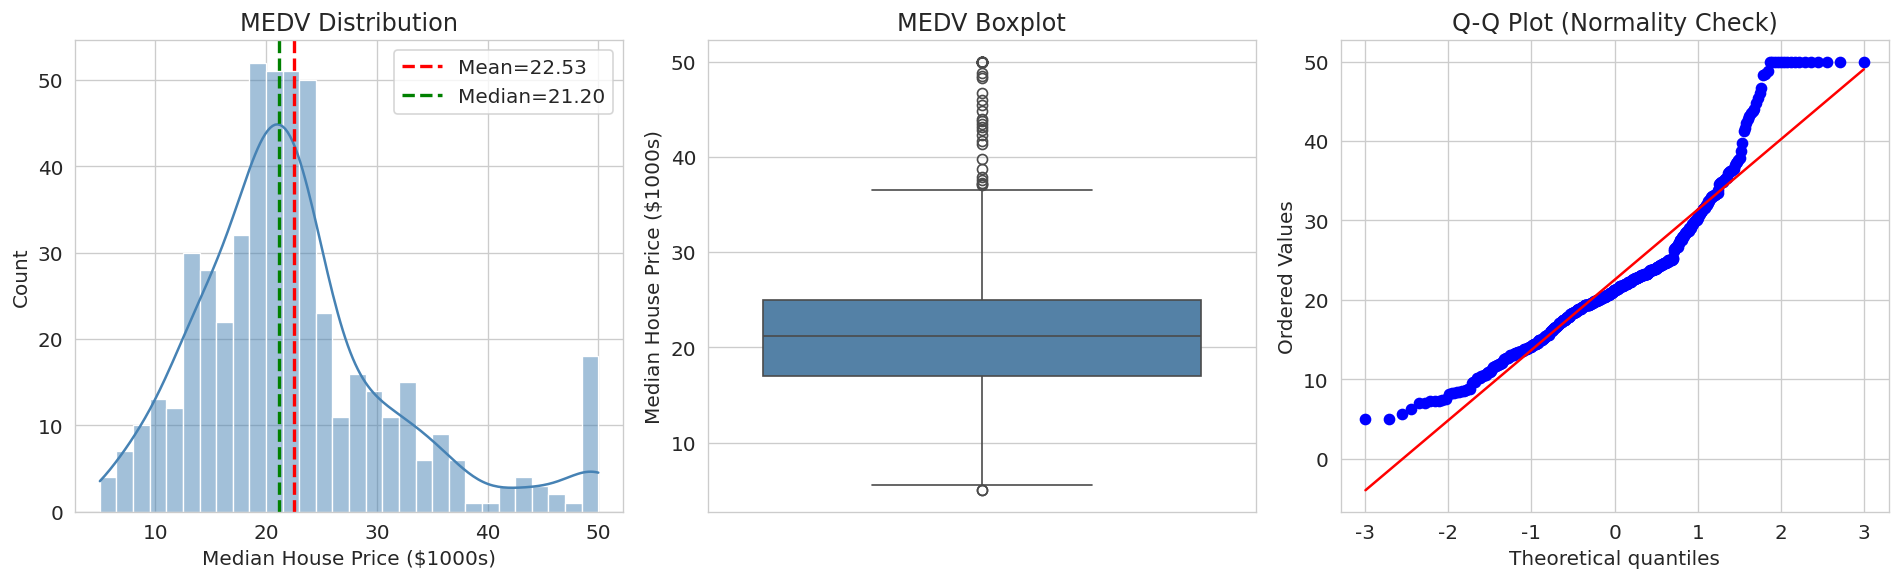

Skewness: 1.108
Kurtosis: 1.495
Right-skewed: most houses are cheap, a few expensive ones stretch the right tail


In [7]:
# ========================================
# 4.1 Target Variable Distribution
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram + KDE
sns.histplot(df['MEDV'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(df['MEDV'].mean(), color='red', ls='--', lw=2, label=f'Mean={df["MEDV"].mean():.2f}')
axes[0].axvline(df['MEDV'].median(), color='green', ls='--', lw=2, label=f'Median={df["MEDV"].median():.2f}')
axes[0].set_title('MEDV Distribution')
axes[0].set_xlabel('Median House Price ($1000s)')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['MEDV'], ax=axes[1], color='steelblue')
axes[1].set_title('MEDV Boxplot')
axes[1].set_ylabel('Median House Price ($1000s)')

# QQ Plot — normality test
stats.probplot(df['MEDV'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['MEDV'].skew():.3f}")
print(f"Kurtosis: {df['MEDV'].kurtosis():.3f}")
print("Right-skewed: most houses are cheap, a few expensive ones stretch the right tail")

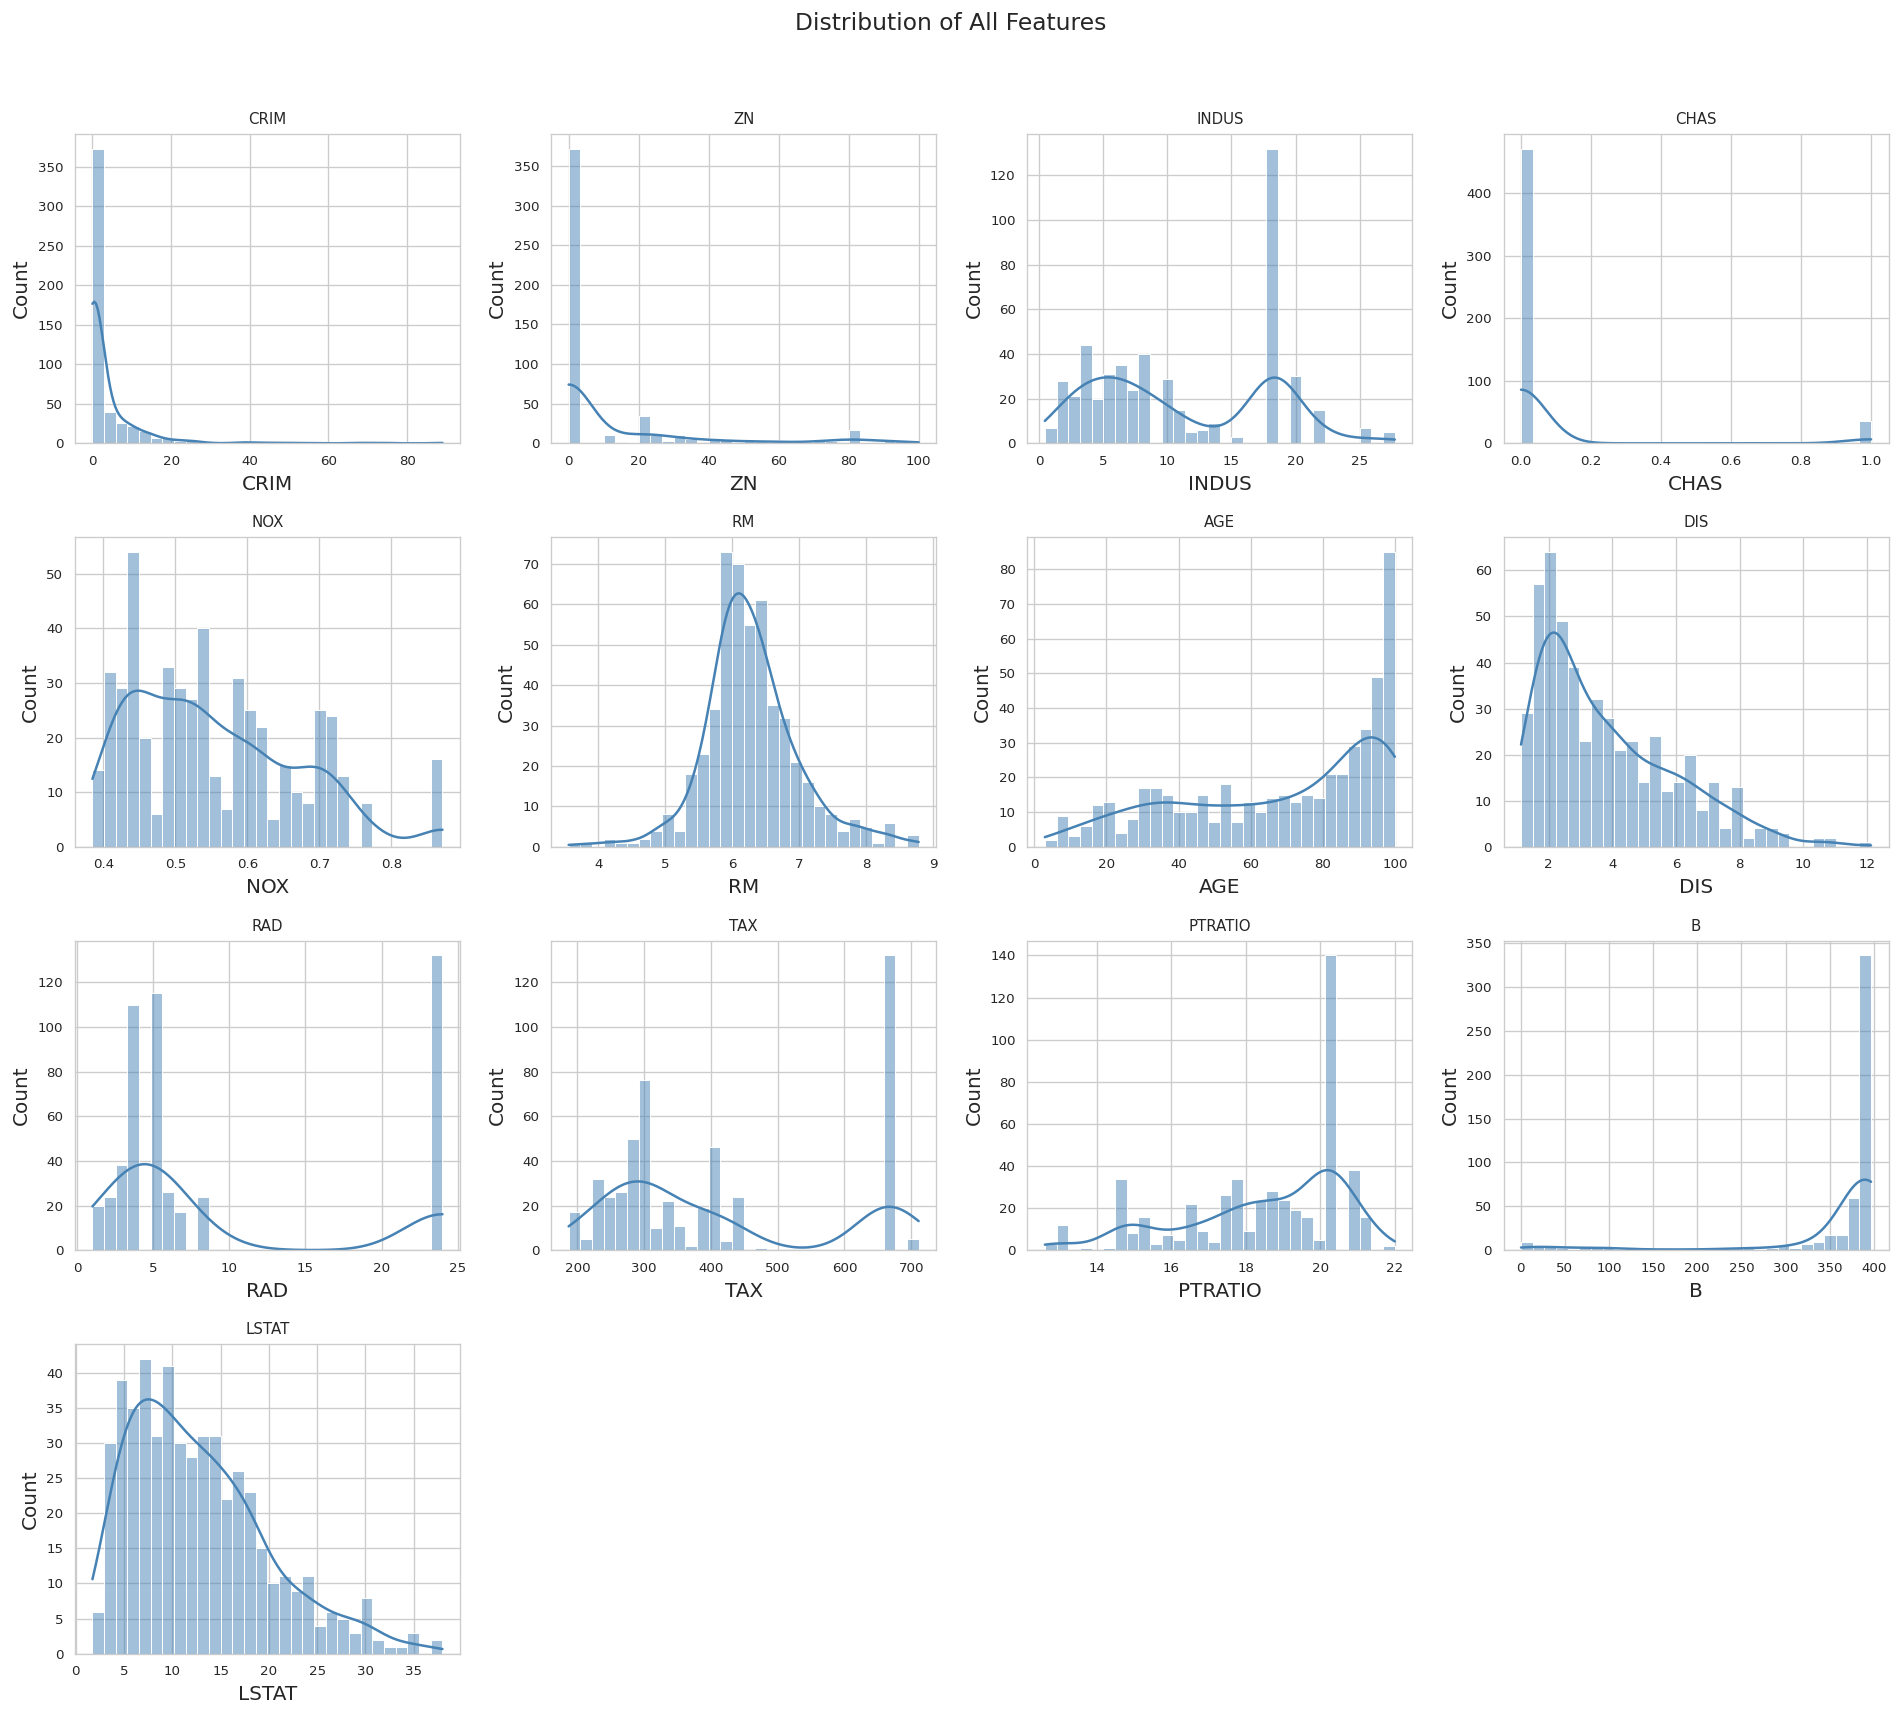

Observation: CRIM, ZN, CHAS, B are heavily skewed; some features are multi-modal


In [8]:
# ========================================
# 4.2 Distribution of All Features
# ========================================

features = [c for c in df.columns if c != 'MEDV']
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.histplot(df[feat], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{feat}', fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Observation: CRIM, ZN, CHAS, B are heavily skewed; some features are multi-modal")

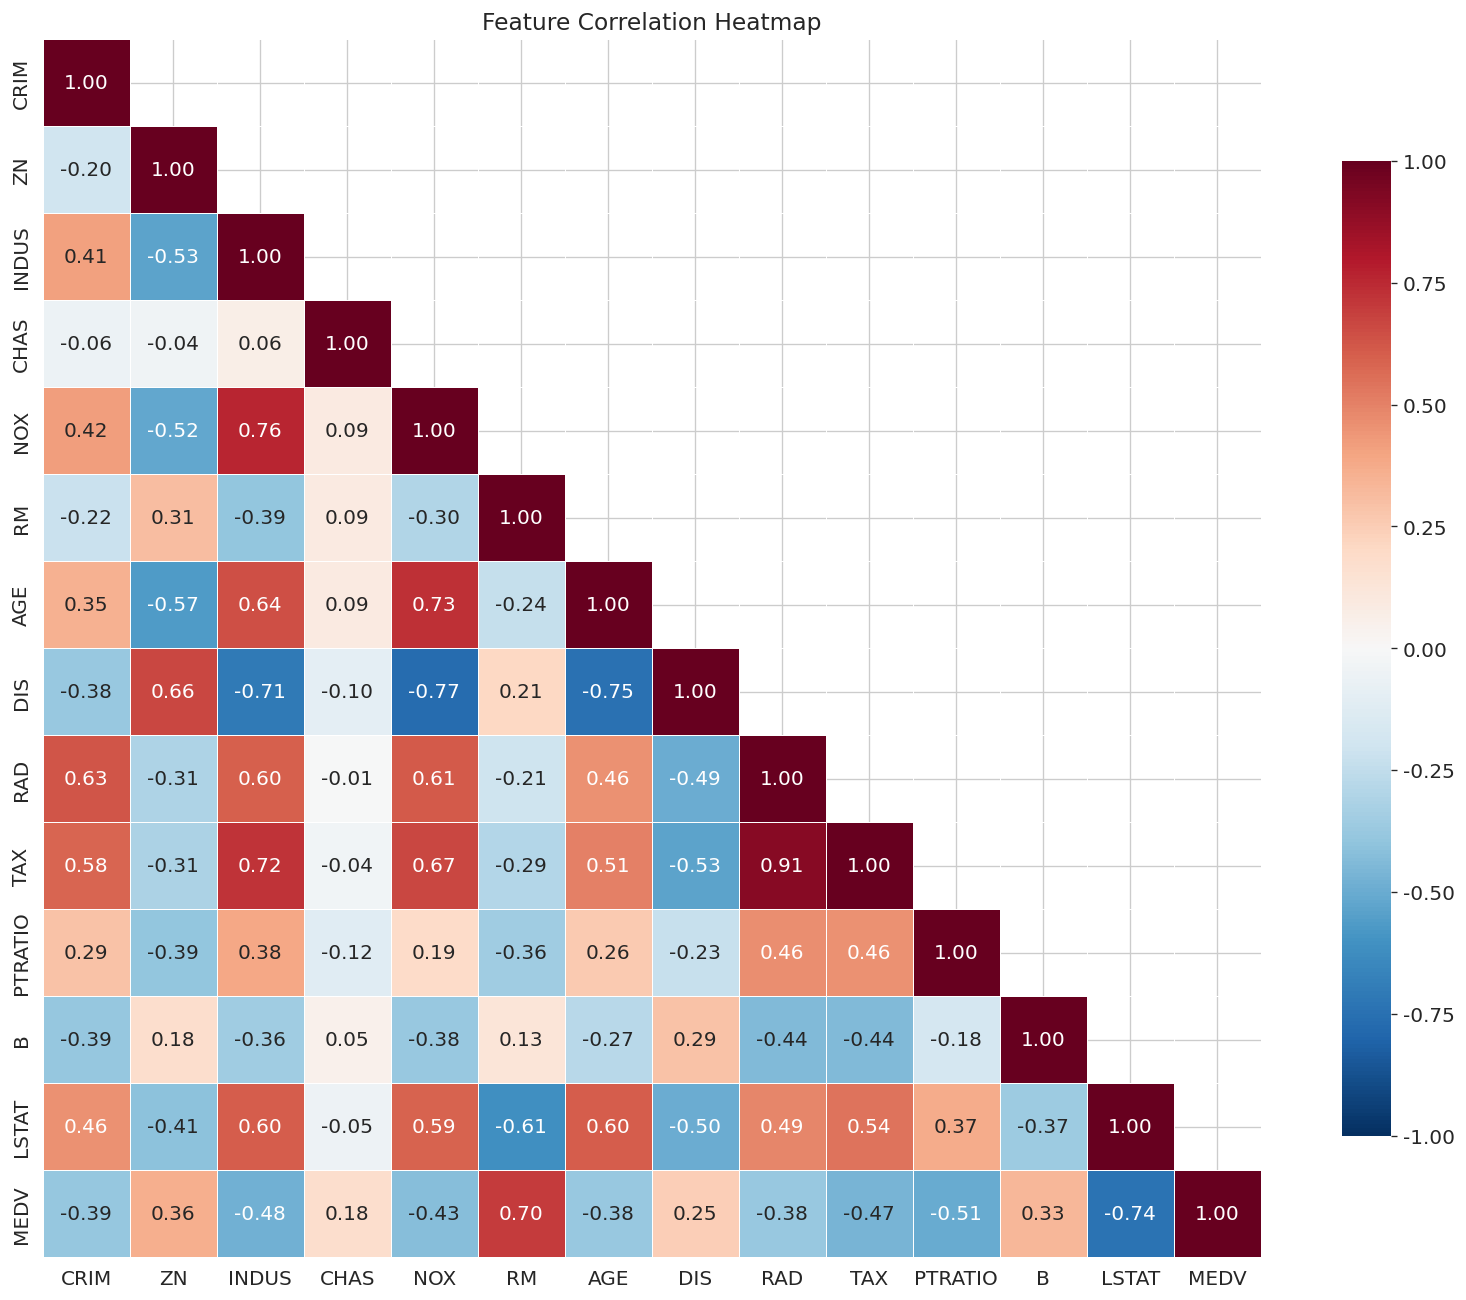

Features most correlated with MEDV: RM (+), LSTAT (-), PTRATIO (-)
Watch for multicollinearity: TAX vs RAD (r=0.91), NOX vs DIS (r=-0.77)


In [9]:
# ========================================
# 4.3 Correlation Heatmap
# ========================================

plt.figure(figsize=(14, 11))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("Features most correlated with MEDV: RM (+), LSTAT (-), PTRATIO (-)")
print("Watch for multicollinearity: TAX vs RAD (r=0.91), NOX vs DIS (r=-0.77)")

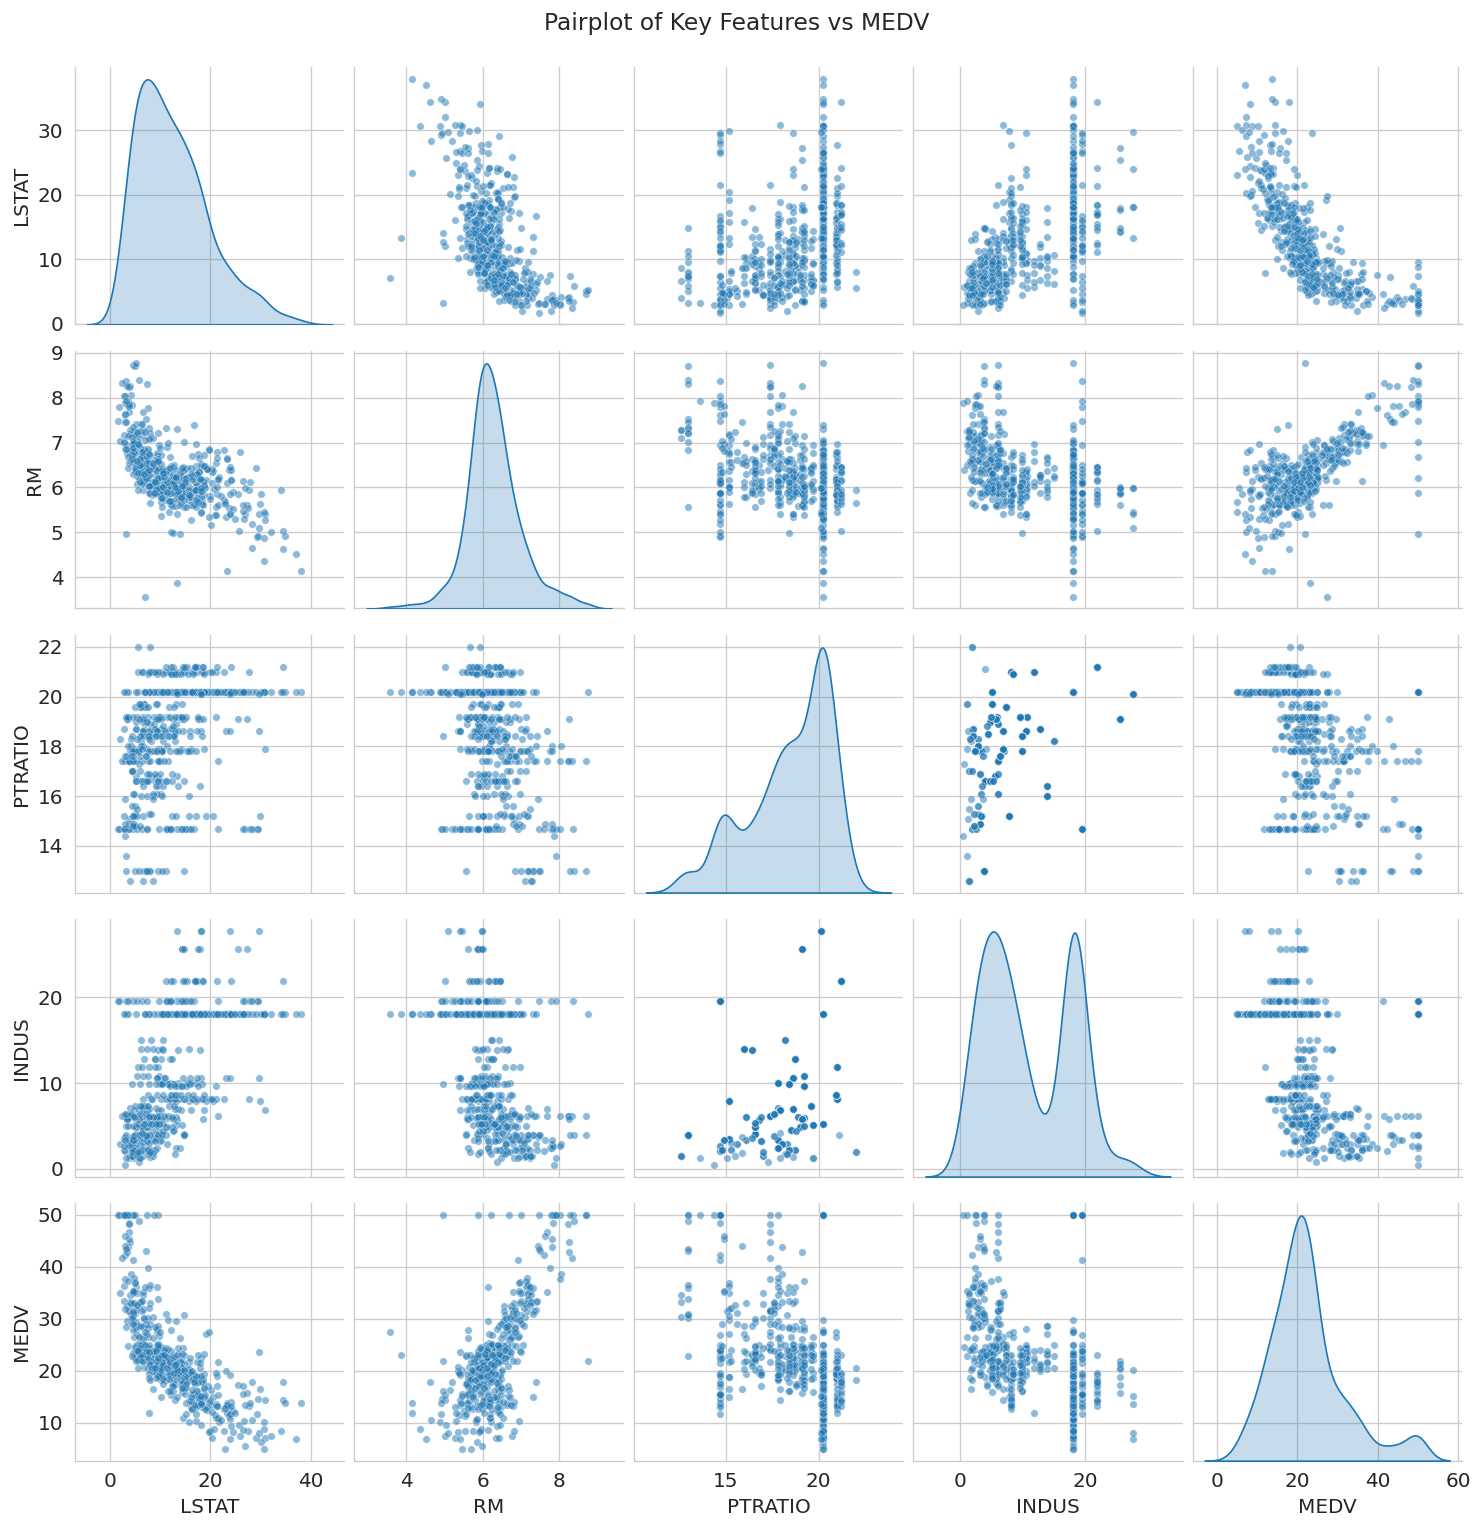

RM shows clear positive linear trend with MEDV; LSTAT shows negative linear trend


In [10]:
# ========================================
# 4.4 Pairplot — Linear Relationships
# ========================================

# Pick the top-4 features most correlated with target
top_features = corr['MEDV'].abs().sort_values(ascending=False).index[1:5].tolist()
selected = top_features + ['MEDV']

sns.pairplot(df[selected], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Key Features vs MEDV', fontsize=14, y=1.02)
plt.show()

print("RM shows clear positive linear trend with MEDV; LSTAT shows negative linear trend")

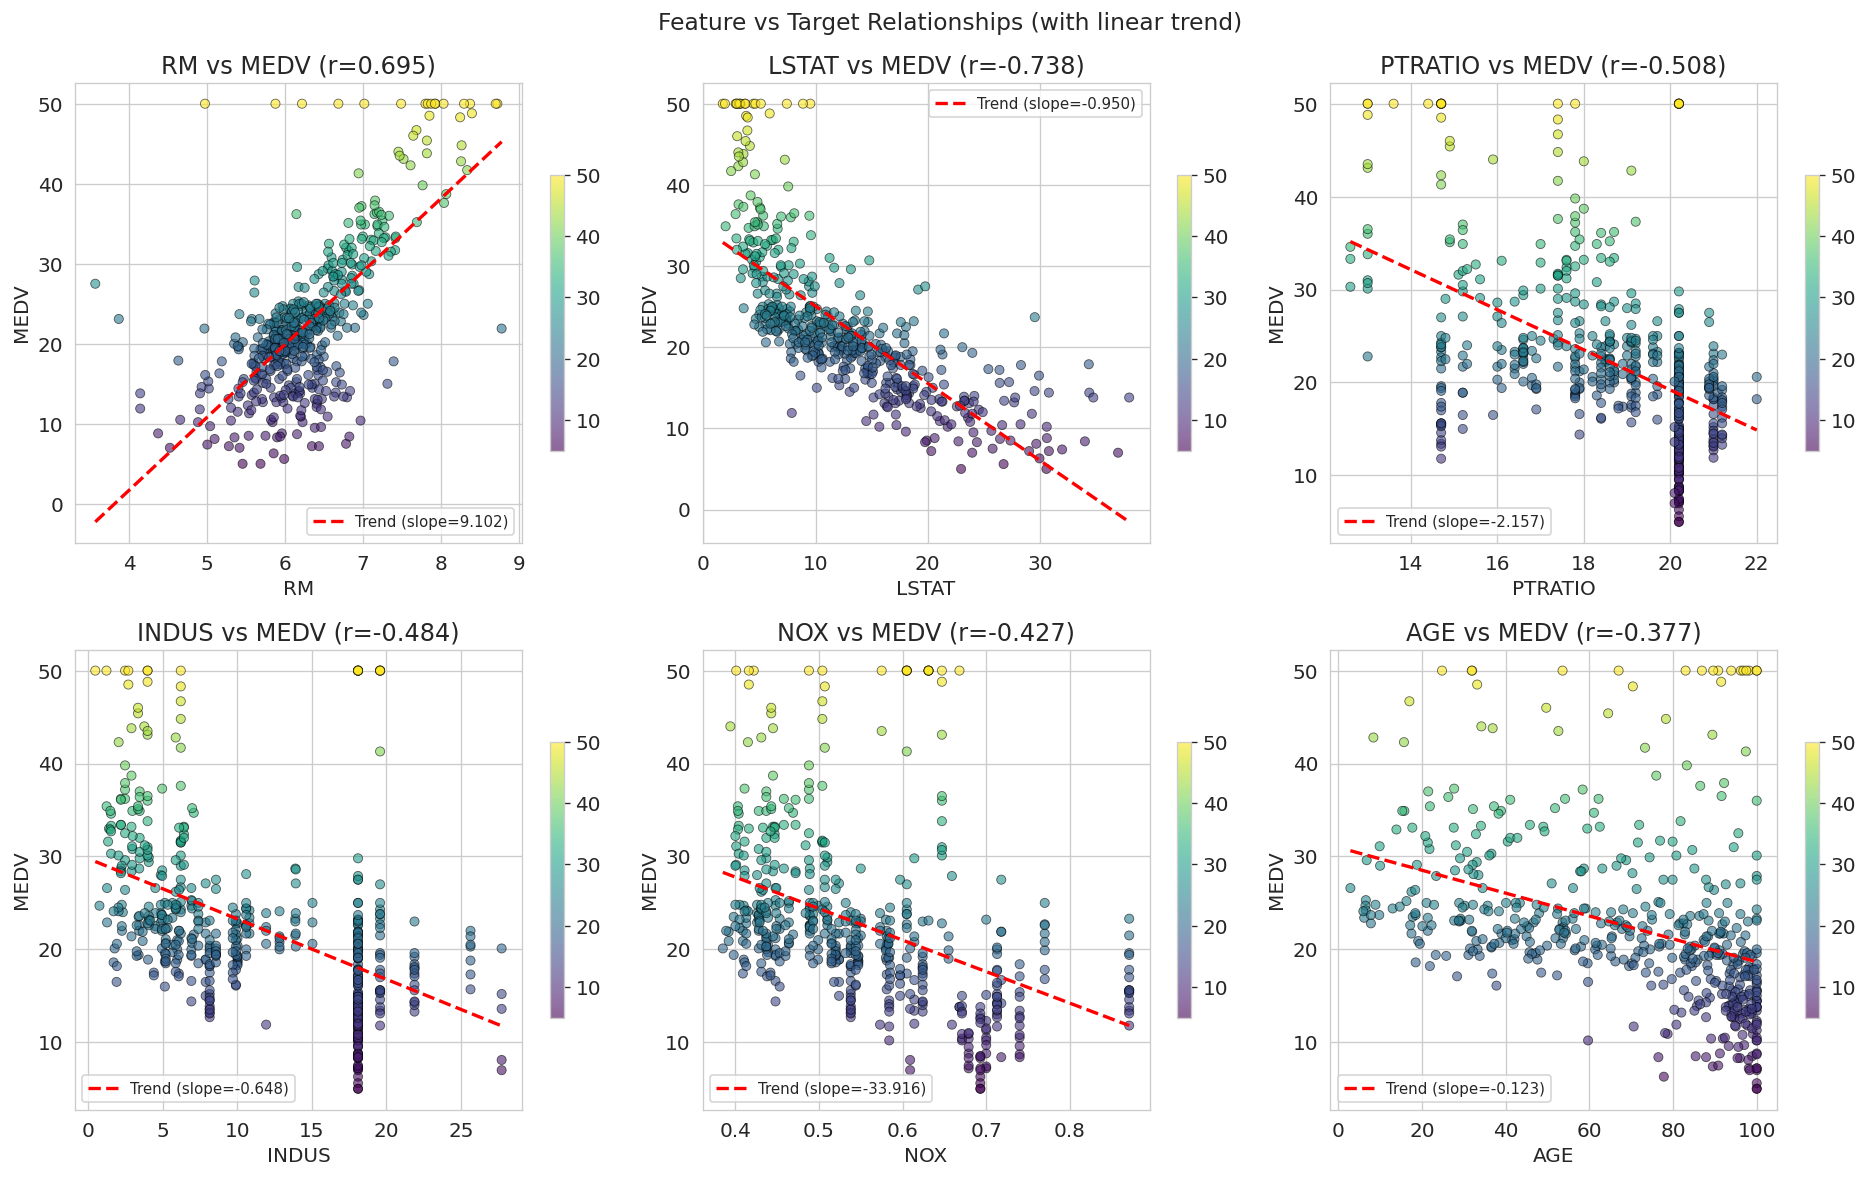

In [11]:
# ========================================
# 4.5 Feature vs Target Relationships
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_plot = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'AGE']

for ax, feat in zip(axes.flatten(), features_plot):
    scatter = ax.scatter(df[feat], df['MEDV'], c=df['MEDV'], cmap='viridis',
                         alpha=0.6, edgecolors='k', linewidth=0.5, s=30)
    
    # Fit trend line
    z = np.polyfit(df[feat], df['MEDV'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[feat])
    ax.plot(x_sorted, p(x_sorted), 'r--', lw=2, label=f'Trend (slope={z[0]:.3f})')
    
    r, _ = stats.pearsonr(df[feat], df['MEDV'])
    ax.set_title(f'{feat} vs MEDV (r={r:.3f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV')
    ax.legend(fontsize=9)
    plt.colorbar(scatter, ax=ax, shrink=0.6)

plt.suptitle('Feature vs Target Relationships (with linear trend)', fontsize=14)
plt.tight_layout()
plt.show()

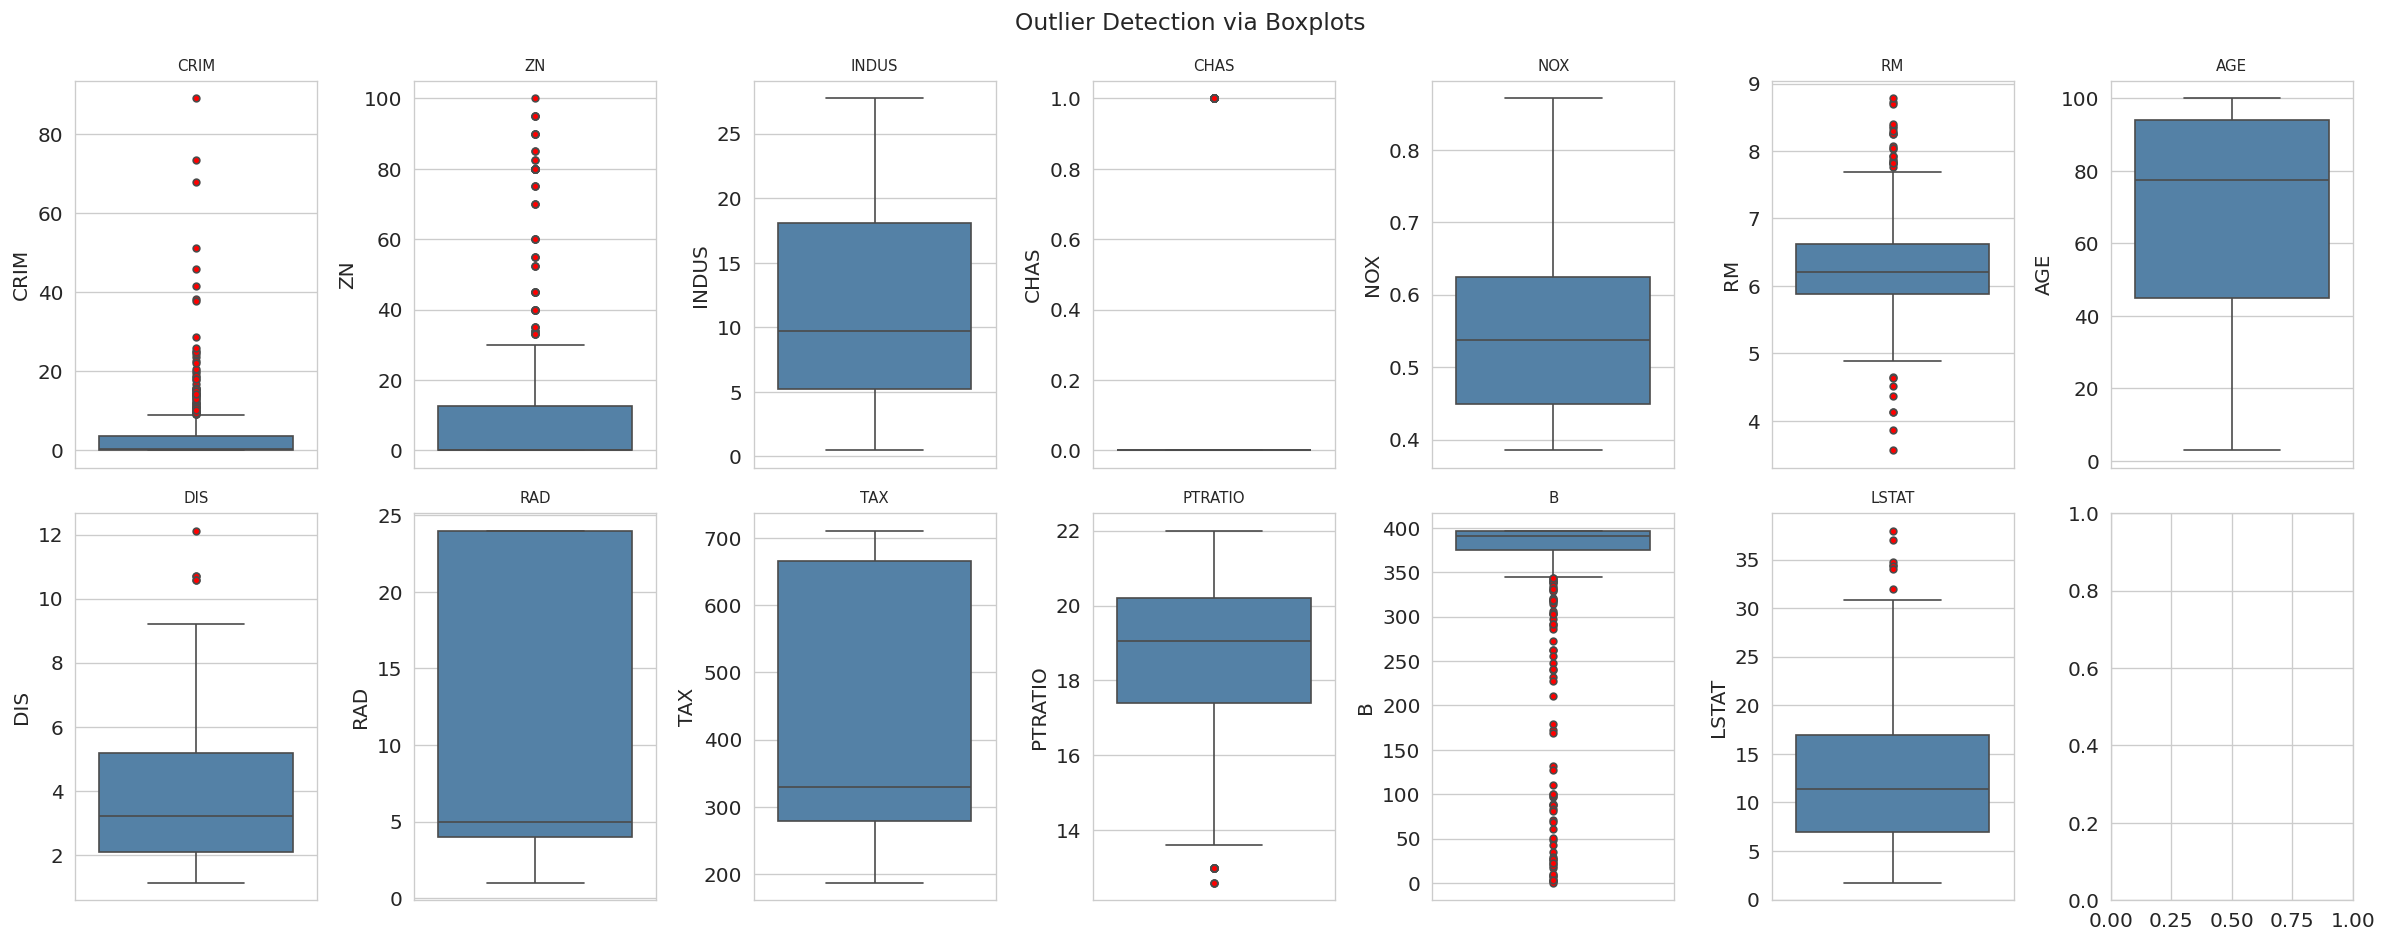

  CRIM    :  66 outliers (13.0%)
  ZN      :  68 outliers (13.4%)
  INDUS   :   0 outliers (0.0%)
  CHAS    :  35 outliers (6.9%)
  NOX     :   0 outliers (0.0%)
  RM      :  30 outliers (5.9%)
  AGE     :   0 outliers (0.0%)
  DIS     :   5 outliers (1.0%)
  RAD     :   0 outliers (0.0%)
  TAX     :   0 outliers (0.0%)
  PTRATIO :  15 outliers (3.0%)
  B       :  77 outliers (15.2%)
  LSTAT   :   7 outliers (1.4%)
  MEDV    :  40 outliers (7.9%)

CRIM and B have many outliers; consider robust methods for modeling


In [12]:
# ========================================
# 4.6 Outlier Detection — Boxplots
# ========================================

fig, axes = plt.subplots(2, 7, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(y=df[feat], ax=axes[i], color='steelblue', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})
    axes[i].set_title(feat, fontsize=9)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

# Count outliers (IQR method)
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in df.columns:
    n_out = count_outliers(df[col])
    print(f"  {col:8s}: {n_out:3d} outliers ({100*n_out/len(df):.1f}%)")

print("\nCRIM and B have many outliers; consider robust methods for modeling")

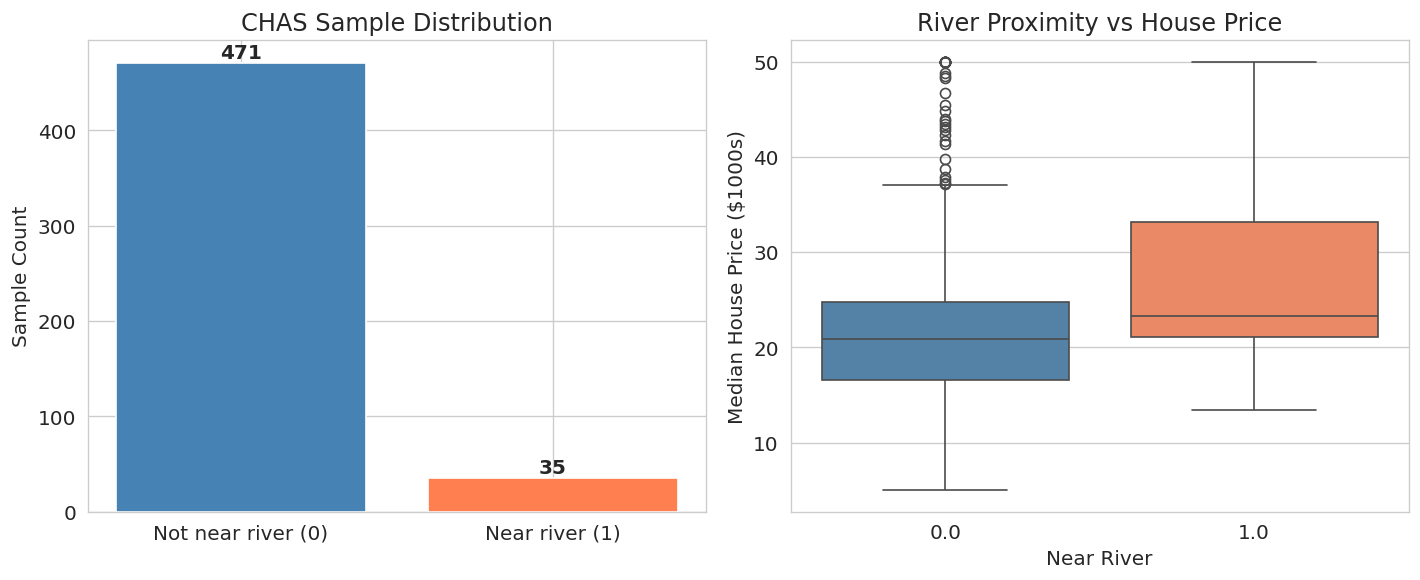

Not near river (0) avg price: 22.09 $1000s
   Near river (1) avg price: 28.44 $1000s
Houses near the Charles River have significantly higher median prices


In [13]:
# ========================================
# 4.7 Categorical Feature: CHAS (River proximity)
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
chas_counts = df['CHAS'].value_counts()
axes[0].bar(['Not near river (0)', 'Near river (1)'], chas_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('CHAS Sample Distribution')
axes[0].set_ylabel('Sample Count')

for i, v in enumerate(chas_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Price comparison
sns.boxplot(x='CHAS', y='MEDV', data=df, ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('River Proximity vs House Price')
axes[1].set_xlabel('Near River')
axes[1].set_ylabel('Median House Price ($1000s)')

plt.tight_layout()
plt.show()

print(f"Not near river (0) avg price: {df[df['CHAS']==0]['MEDV'].mean():.2f} $1000s")
print(f"   Near river (1) avg price: {df[df['CHAS']==1]['MEDV'].mean():.2f} $1000s")
print("Houses near the Charles River have significantly higher median prices")

---
## 5. Prepare Training Data

In [14]:
# ========================
# 5. Data Preprocessing
# ========================

X = df.drop(columns=['MEDV']).values.astype(float)
y = df['MEDV'].values.astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

# Standardization (important for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: 404 samples
Test set: 102 samples


---
## 6. Evaluation Metrics

> Before building models, let's understand how to evaluate them.

In [15]:
# ========================
# 6. Regression Metrics with Formulas
# ========================

print("=" * 65)
print("Regression Evaluation Metrics")
print("=" * 65)
print()
print("1.  Mean Squared Error (MSE)")
print("    MSE = (1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²")
print("    → Penalizes large errors more, unit is squared")
print()
print("2.  Root Mean Squared Error (RMSE)")
print("    RMSE = √MSE = √[(1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²]")
print("    → Same unit as y, more interpretable")
print()
print("3.  Mean Absolute Error (MAE)")
print("    MAE = (1/n) Σᵢ₌₁ⁿ |yᵢ - ŷᵢ|")
print("    → Robust to outliers, same unit as y")
print()
print("4.  Mean Absolute Percentage Error (MAPE)")
print("    MAPE = (100%/n) Σᵢ₌₁ⁿ |(yᵢ - ŷᵢ) / yᵢ|")
print("    → Relative error, unitless, undefined when y=0")
print()
print("5.  Coefficient of Determination (R²)")
print("    R² = 1 - Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)² / Σᵢ₌₁ⁿ (yᵢ - ȳ)²")
print("    → Proportion of variance explained, best = 1")
print()
print("6.  Std of Residuals")
print("    σ_res = √[(1/n) Σᵢ₌₁ⁿ (eᵢ - ē)²], eᵢ = yᵢ - ŷᵢ")
print("    → Measures dispersion of prediction errors")
print()
print("7.  Mean Absolute Deviation (MAD)")
print("    MAD = (1/n) Σᵢ₌₁ⁿ |eᵢ - median(e)|")
print("    → Robust dispersion measure around residual median")
print()
print("8.  KL Divergence (Kullback-Leibler)")
print("    D_KL(P||Q) = Σ P(x) · log(P(x) / Q(x))")
print("    → Measures difference between true (P) and predicted (Q) distributions")
print("    → Note: asymmetric, needs discretization for continuous values")
print()
print("9.  Residual Skewness")
print("    Measures symmetry of residual distribution, ideal = 0")

Regression Evaluation Metrics

1.  Mean Squared Error (MSE)
    MSE = (1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²
    → Penalizes large errors more, unit is squared

2.  Root Mean Squared Error (RMSE)
    RMSE = √MSE = √[(1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²]
    → Same unit as y, more interpretable

3.  Mean Absolute Error (MAE)
    MAE = (1/n) Σᵢ₌₁ⁿ |yᵢ - ŷᵢ|
    → Robust to outliers, same unit as y

4.  Mean Absolute Percentage Error (MAPE)
    MAPE = (100%/n) Σᵢ₌₁ⁿ |(yᵢ - ŷᵢ) / yᵢ|
    → Relative error, unitless, undefined when y=0

5.  Coefficient of Determination (R²)
    R² = 1 - Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)² / Σᵢ₌₁ⁿ (yᵢ - ȳ)²
    → Proportion of variance explained, best = 1

6.  Std of Residuals
    σ_res = √[(1/n) Σᵢ₌₁ⁿ (eᵢ - ē)²], eᵢ = yᵢ - ŷᵢ
    → Measures dispersion of prediction errors

7.  Mean Absolute Deviation (MAD)
    MAD = (1/n) Σᵢ₌₁ⁿ |eᵢ - median(e)|
    → Robust dispersion measure around residual median

8.  KL Divergence (Kullback-Leibler)
    D_KL(P||Q) = Σ P(x) · log(P(x) / Q(x))
    → Measures difference be

In [16]:
# ========================
# 7. Helper Functions
# ========================

def compute_metrics(y_true, y_pred, prefix=''):
    residuals = y_true - y_pred
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    residual_std = np.std(residuals, ddof=1)
    mad = np.mean(np.abs(residuals - np.median(residuals)))
    residual_skew = stats.skew(residuals)
    
    # KL Divergence: discretize both distributions into histograms
    bins = 30
    hist_true, bin_edges = np.histogram(y_true, bins=bins, density=True)
    hist_pred, _ = np.histogram(y_pred, bins=bin_edges, density=True)
    hist_true_smooth = hist_true + 1e-12
    hist_pred_smooth = hist_pred + 1e-12
    hist_true_smooth /= hist_true_smooth.sum()
    hist_pred_smooth /= hist_pred_smooth.sum()
    kl_div = entropy(hist_true_smooth, hist_pred_smooth)
    
    metrics = {
        f'{prefix}MSE': mse,
        f'{prefix}RMSE': rmse,
        f'{prefix}MAE': mae,
        f'{prefix}MAPE(%)': mape,
        f'{prefix}R²': r2,
        f'{prefix}Residual Std': residual_std,
        f'{prefix}MAD': mad,
        f'{prefix}Residual Skew': residual_skew,
        f'{prefix}KL Div': kl_div
    }
    return metrics


def train_and_evaluate(model, model_name, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)
    
    train_metrics = compute_metrics(y_tr, y_pred_train, 'Train_')
    test_metrics = compute_metrics(y_te, y_pred_test, 'Test_')
    
    metrics = {**train_metrics, **test_metrics}
    metrics['Model'] = model_name
    return metrics, y_pred_test


print('Helper functions ready')

Helper functions ready


---
## 8. Multi-Model Comparison

We will train 5 classic models:
1. **Linear Regression** — baseline, assumes linearity
2. **Ridge Regression** — L2 regularization, mitigates multicollinearity
3. **Lasso Regression** — L1 regularization, automatic feature selection
4. **Decision Tree Regressor** — non-linear, interpretable
5. **Random Forest Regressor** — ensemble learning, usually best performer

In [17]:
# ========================
# 8. Train All Models
# ========================

# Linear models need scaling, tree models don't
models = [
    (LinearRegression(), 'Linear Regression', True),
    (Ridge(alpha=1.0), 'Ridge Regression', True),
    (Lasso(alpha=0.1), 'Lasso Regression', True),
    (DecisionTreeRegressor(max_depth=5, random_state=42), 'Decision Tree', False),
    (RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42), 'Random Forest', False)
]

all_metrics = []
predictions = {}

for model, name, needs_scaling in models:
    if needs_scaling:
        metrics, y_pred = train_and_evaluate(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    else:
        metrics, y_pred = train_and_evaluate(model, name, X_train, X_test, y_train, y_test)
    all_metrics.append(metrics)
    predictions[name] = y_pred

metrics_df = pd.DataFrame(all_metrics).set_index('Model')
metrics_df

,Train_MSE,Train_RMSE,Train_MAE,Train_MAPE(%),Train_R²,Train_Residual Std,Train_MAD,Train_Residual Skew,Train_KL Div,Test_MSE,Test_RMSE,Test_MAE,Test_MAPE(%),Test_R²,Test_Residual Std,Test_MAD,Test_Residual Skew,Test_KL Div
Model,,,,,,,,,,,,,,,,,,
Linear Regression,21.641413,4.652033,3.314772,16.574914,0.750886,4.657801,3.264833,1.378837,1.016066,24.291119,4.928602,3.189092,16.866395,0.668759,4.947268,3.120298,2.064225,2.955554
Ridge Regression,21.642751,4.652177,3.308708,16.537915,0.750870,4.657945,3.260108,1.389758,1.015910,24.312904,4.930812,3.185724,16.854676,0.668462,4.949390,3.116267,2.076398,2.967961
Lasso Regression,22.149497,4.706325,3.265766,16.244387,0.745037,4.712161,3.221567,1.515739,1.175148,25.656739,5.065248,3.241803,17.286382,0.650138,5.082048,3.146656,2.135955,3.231240
Decision Tree,7.078697,2.660582,1.963783,10.281408,0.918517,2.663881,1.963783,0.143616,3.787528,8.553907,2.924706,2.308157,13.089061,0.883357,2.926857,2.282330,-0.224736,5.508420
Random Forest,2.231406,1.493789,1.027927,5.151230,0.974314,1.495544,1.027224,-0.152145,0.235436,7.758827,2.785467,2.013292,10.982493,0.894198,2.795494,2.012551,-0.893568,2.051063


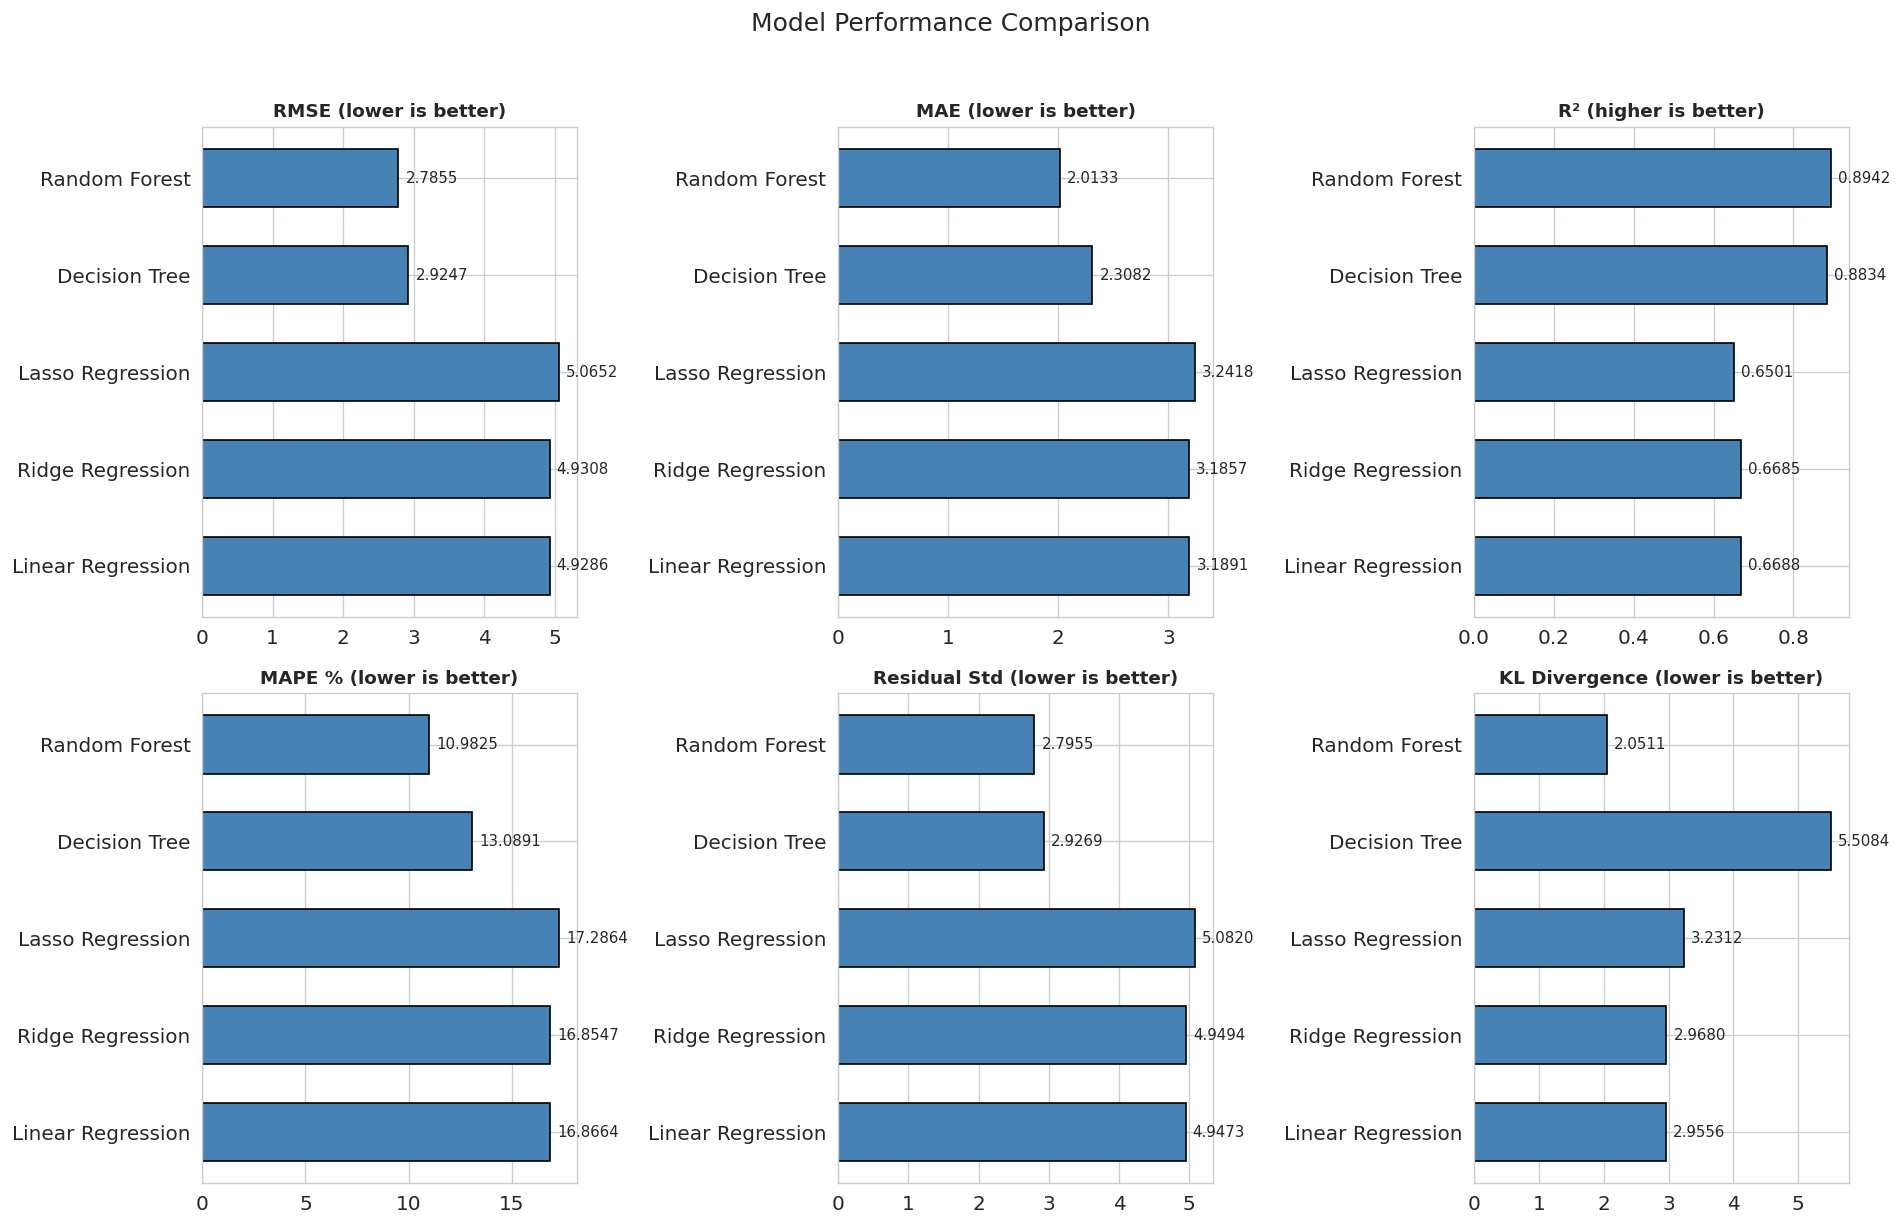

Best Test R²: Random Forest (R² = 0.8942)
Worst Test RMSE: Lasso Regression (RMSE = 5.0652)


In [18]:
# ========================================
# 8.1 Model Performance Visualization
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_metrics = ['Test_RMSE', 'Test_MAE', 'Test_R²', 
                'Test_MAPE(%)', 'Test_Residual Std', 'Test_KL Div']
titles = ['RMSE (lower is better)', 'MAE (lower is better)', 'R² (higher is better)',
          'MAPE % (lower is better)', 'Residual Std (lower is better)', 'KL Divergence (lower is better)']

for ax, metric, title in zip(axes.flatten(), plot_metrics, titles):
    values = metrics_df[metric]
    bars = ax.barh(values.index, values.values, color='steelblue', edgecolor='black', height=0.6)
    
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.02 * values.max(), bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Model Performance Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

best_r2 = metrics_df['Test_R²'].idxmax()
print(f"Best Test R²: {best_r2} (R² = {metrics_df.loc[best_r2, 'Test_R²']:.4f})")

worst_rmse = metrics_df['Test_RMSE'].idxmax()
print(f"Worst Test RMSE: {worst_rmse} (RMSE = {metrics_df.loc[worst_rmse, 'Test_RMSE']:.4f})")

---
## 9. Residual Analysis

> Residual = True value - Predicted value. A good model's residuals should:
> 1. Have mean = 0
> 2. Follow a normal distribution
> 3. Show no obvious pattern (homoscedasticity)

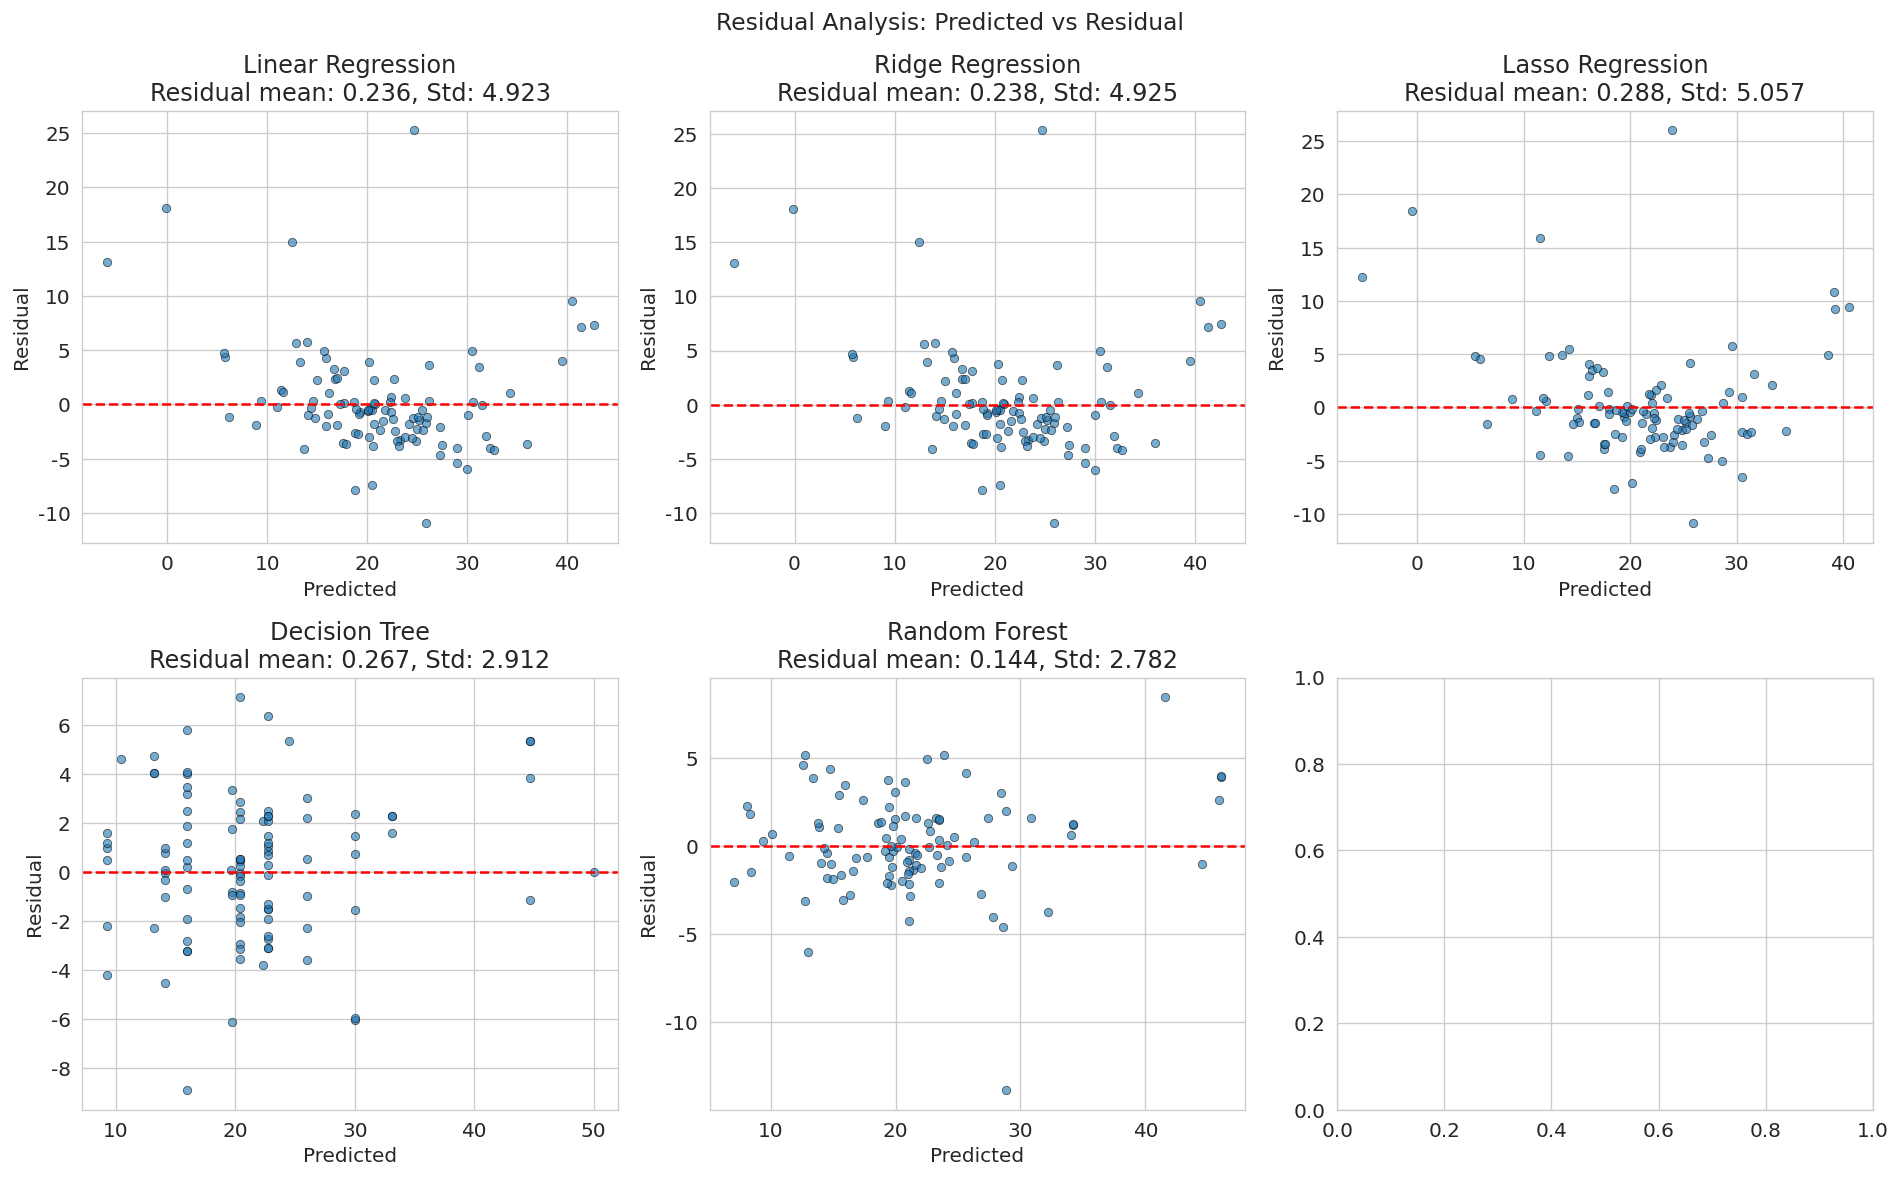

Ideal: residuals randomly scattered around y=0, no funnel or curve patterns


In [19]:
# ========================================
# 9. Residual Analysis
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    row = idx // 3
    col = idx % 3
    residuals = y_test - y_pred
    
    axes[row, col].scatter(y_pred, residuals, alpha=0.6, s=25, edgecolors='k', linewidth=0.5)
    axes[row, col].axhline(y=0, color='red', ls='--', lw=1.5)
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Residual')
    axes[row, col].set_title(f'{model_name}\nResidual mean: {residuals.mean():.3f}, Std: {residuals.std():.3f}')

plt.suptitle('Residual Analysis: Predicted vs Residual', fontsize=14)
plt.tight_layout()
plt.show()

print("Ideal: residuals randomly scattered around y=0, no funnel or curve patterns")

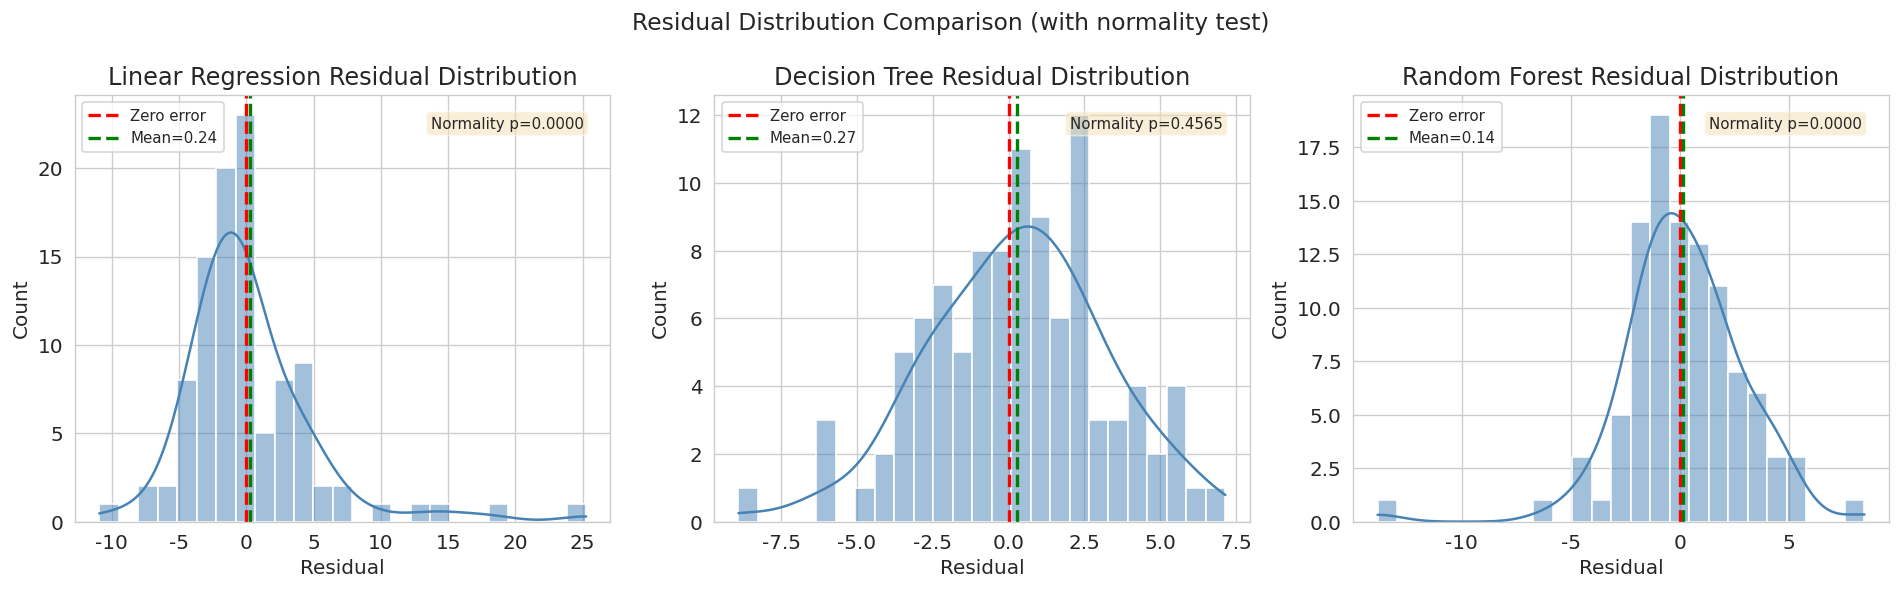

p > 0.05 means residuals are approximately normal (cannot reject normality)


In [20]:
# ========================================
# 9.1 Residual Distribution Histograms
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_models = ['Linear Regression', 'Decision Tree', 'Random Forest']

for idx, model_name in enumerate(plot_models):
    residuals = y_test - predictions[model_name]
    
    sns.histplot(residuals, kde=True, bins=25, ax=axes[idx], color='steelblue')
    axes[idx].axvline(x=0, color='red', ls='--', lw=2, label='Zero error')
    axes[idx].axvline(x=residuals.mean(), color='green', ls='--', lw=2, 
                      label=f'Mean={residuals.mean():.2f}')
    axes[idx].set_title(f'{model_name} Residual Distribution')
    axes[idx].set_xlabel('Residual')
    axes[idx].legend(fontsize=9)
    
    _, p_value = stats.normaltest(residuals)
    axes[idx].text(0.95, 0.95, f'Normality p={p_value:.4f}', 
                  transform=axes[idx].transAxes, ha='right', va='top', 
                  fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Residual Distribution Comparison (with normality test)', fontsize=14)
plt.tight_layout()
plt.show()

print("p > 0.05 means residuals are approximately normal (cannot reject normality)")

---
## 10. Key Experiment: Impact of Data Size

> **Core Question**: How does model performance change when training data decreases?
> We train the same model with different fractions of data (10%, 20%, ..., 100%) and observe performance.
> This is the best way to understand **"Data is fuel"**.

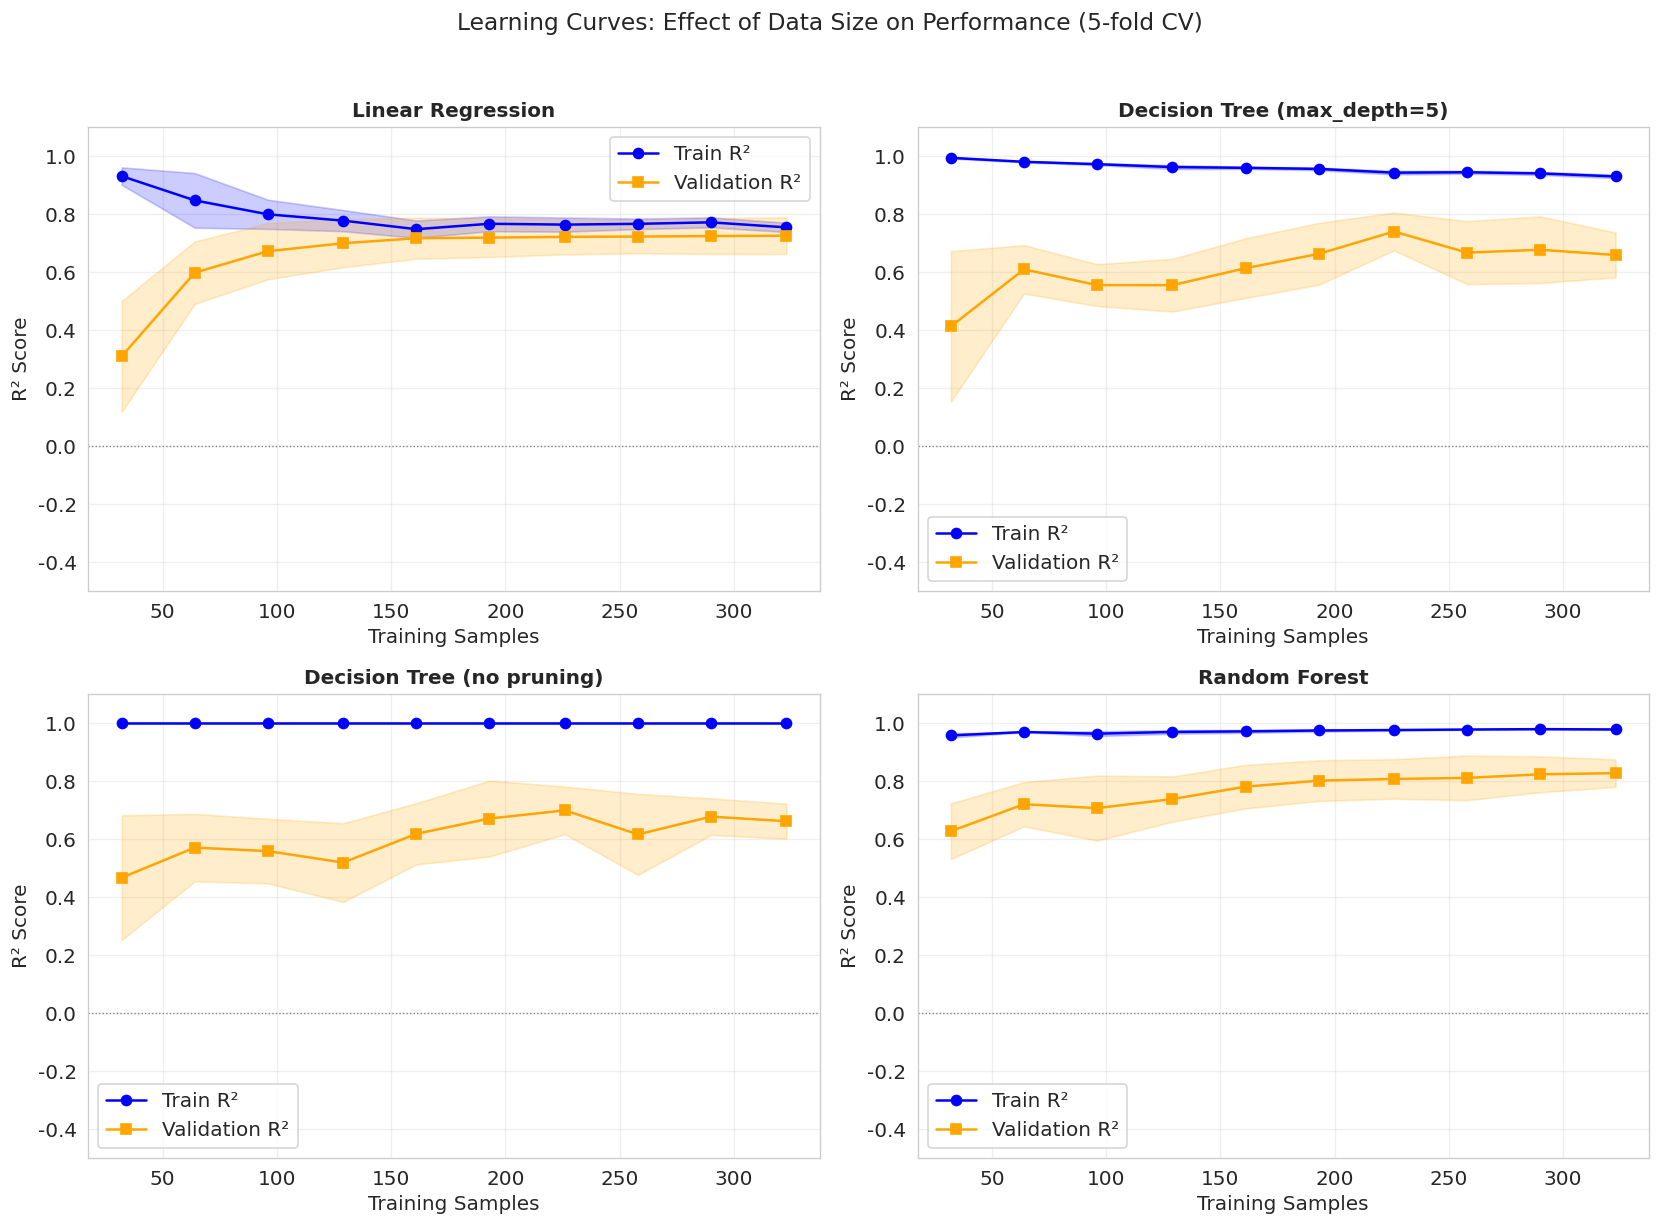

Interpretation:
  - Linear model: train and validation curves converge, low bias, limited gain from more data
  - Decision Tree (no pruning): Train R² near 1 always (overfitting), low validation R²
  - Decision Tree (pruned): less overfitting, more data helps
  - Random Forest: highest validation R², steadily improves with more data


In [21]:
# ========================================
# 10. Learning Curves
# ========================================

train_sizes = np.linspace(0.1, 1.0, 10)

lc_models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree (max_depth=5)', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('Decision Tree (no pruning)', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42))
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, model) in zip(axes.flatten(), lc_models):
    needs_scaling = name == 'Linear Regression'
    X_tr = X_train_scaled if needs_scaling else X_train
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_tr, y_train,
        train_sizes=train_sizes, cv=5, scoring='r2', 
        n_jobs=-1, random_state=42)
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                    alpha=0.2, color='blue')
    ax.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, 
                    alpha=0.2, color='orange')
    ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Train R²')
    ax.plot(train_sizes_abs, test_mean, 's-', color='orange', label='Validation R²')
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('R² Score')
    ax.legend(loc='best')
    ax.set_ylim(-0.5, 1.1)
    ax.axhline(y=0, color='gray', ls=':', lw=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Effect of Data Size on Performance (5-fold CV)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - Linear model: train and validation curves converge, low bias, limited gain from more data")
print("  - Decision Tree (no pruning): Train R² near 1 always (overfitting), low validation R²")
print("  - Decision Tree (pruned): less overfitting, more data helps")
print("  - Random Forest: highest validation R², steadily improves with more data")

In [22]:
# ========================================
# 10.1 Performance vs Data Fraction
# ========================================

data_fractions = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

results_by_fraction = []

np.random.seed(42)

for frac in data_fractions:
    n_samples = int(len(X_train) * frac)
    idx_subset = np.random.choice(len(X_train), n_samples, replace=False)
    
    X_sub = X_train_scaled[idx_subset]
    y_sub = y_train[idx_subset]
    
    for model, name, needs_scaling in models:
        if needs_scaling:
            X_tr = X_sub
        else:
            X_tr = X_train[idx_subset]
        
        m = type(model)(**model.get_params()) if hasattr(model, 'get_params') else model.__class__()
        if hasattr(model, 'get_params'):
            m.set_params(**model.get_params())
        m.fit(X_tr, y_sub)
        
        y_pred_te = m.predict(X_test_scaled if needs_scaling else X_test)
        r2 = r2_score(y_test, y_pred_te)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_te))
        
        results_by_fraction.append({
            'Data Fraction': frac,
            'Samples': n_samples,
            'Model': name,
            'R²': r2,
            'RMSE': rmse
        })

frac_df = pd.DataFrame(results_by_fraction)
frac_df

,Data Fraction,Samples,Model,R²,RMSE
0,0.05,20,Linear Regression,0.602289,5.400522
1,0.05,20,Ridge Regression,0.617431,5.296718
2,0.05,20,Lasso Regression,0.622953,5.258355
3,0.05,20,Decision Tree,0.385858,6.710989
4,0.05,20,Random Forest,0.528764,5.878565
5,0.10,40,Linear Regression,0.653825,5.038481
6,0.10,40,Ridge Regression,0.670483,4.915767
7,0.10,40,Lasso Regression,0.659658,4.995854
8,0.10,40,Decision Tree,0.540327,5.805995
9,0.10,40,Random Forest,0.648151,5.079607


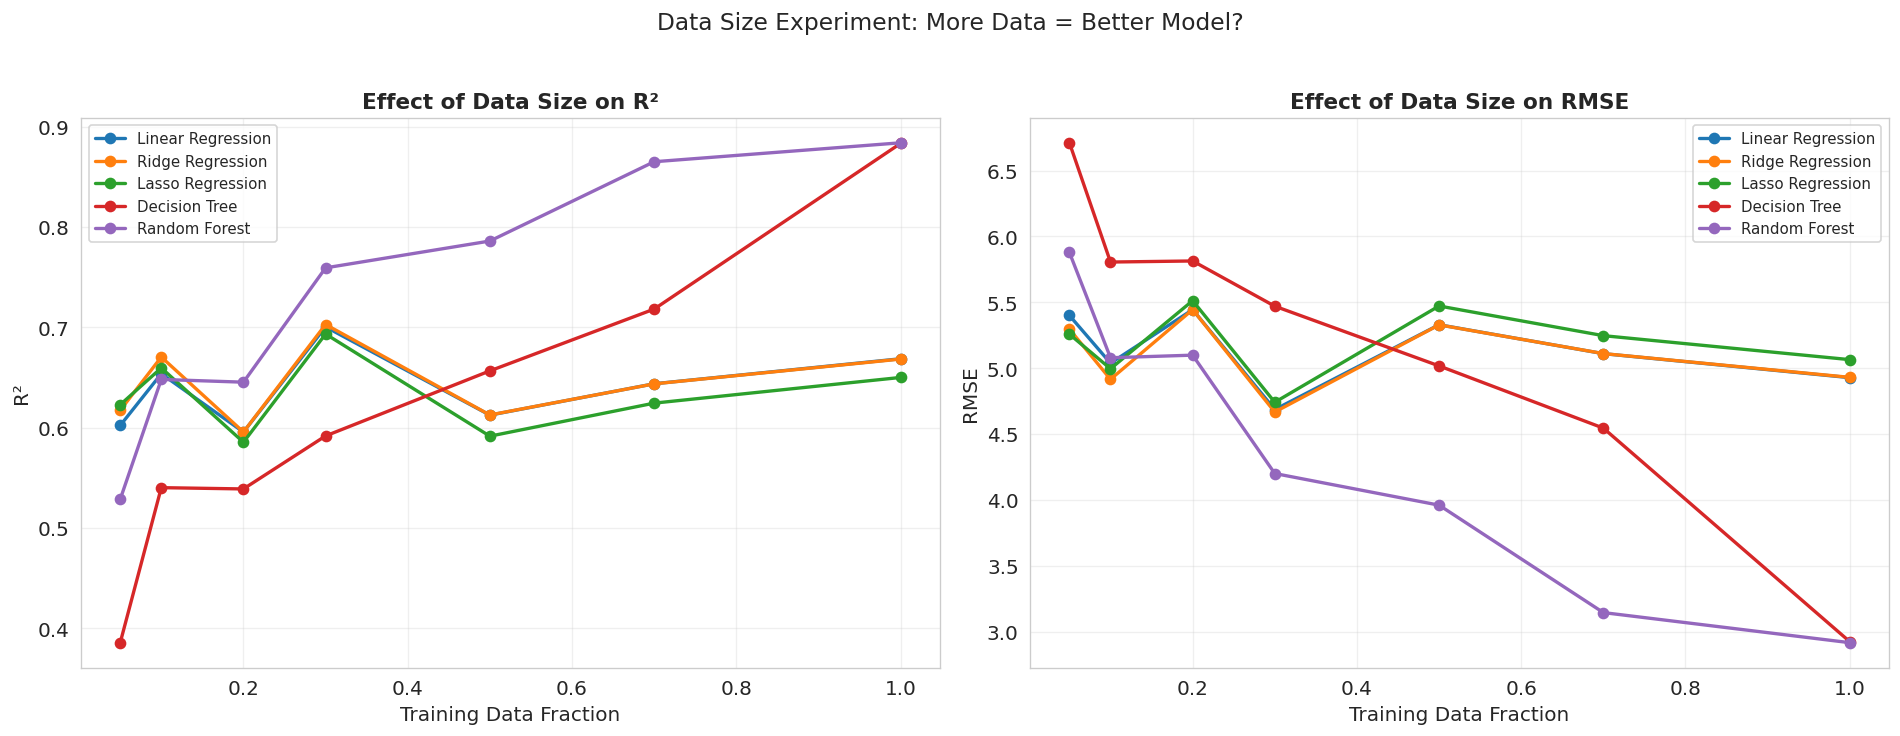

Key Takeaways:
  - Overall: more data improves performance (R² ↑, RMSE ↓)
  - Linear model: works decently even with little data (low variance)
  - Decision Tree: severe overfitting with little data, R² can be negative
  - Random Forest: benefits most from more data, but underperforms linear model with very little data
  - Insight: complex models need more data; simple models are more reliable with small datasets


In [23]:
# ========================================
# 10.2 Data Size vs Performance Curves
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ['R²', 'RMSE']):
    for model_name in frac_df['Model'].unique():
        sub = frac_df[frac_df['Model'] == model_name]
        ax.plot(sub['Data Fraction'], sub[metric], 'o-', label=model_name, linewidth=2)
    
    ax.set_xlabel('Training Data Fraction', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'Effect of Data Size on {metric}', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Data Size Experiment: More Data = Better Model?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Key Takeaways:")
print("  - Overall: more data improves performance (R² ↑, RMSE ↓)")
print("  - Linear model: works decently even with little data (low variance)")
print("  - Decision Tree: severe overfitting with little data, R² can be negative")
print("  - Random Forest: benefits most from more data, but underperforms linear model with very little data")
print("  - Insight: complex models need more data; simple models are more reliable with small datasets")

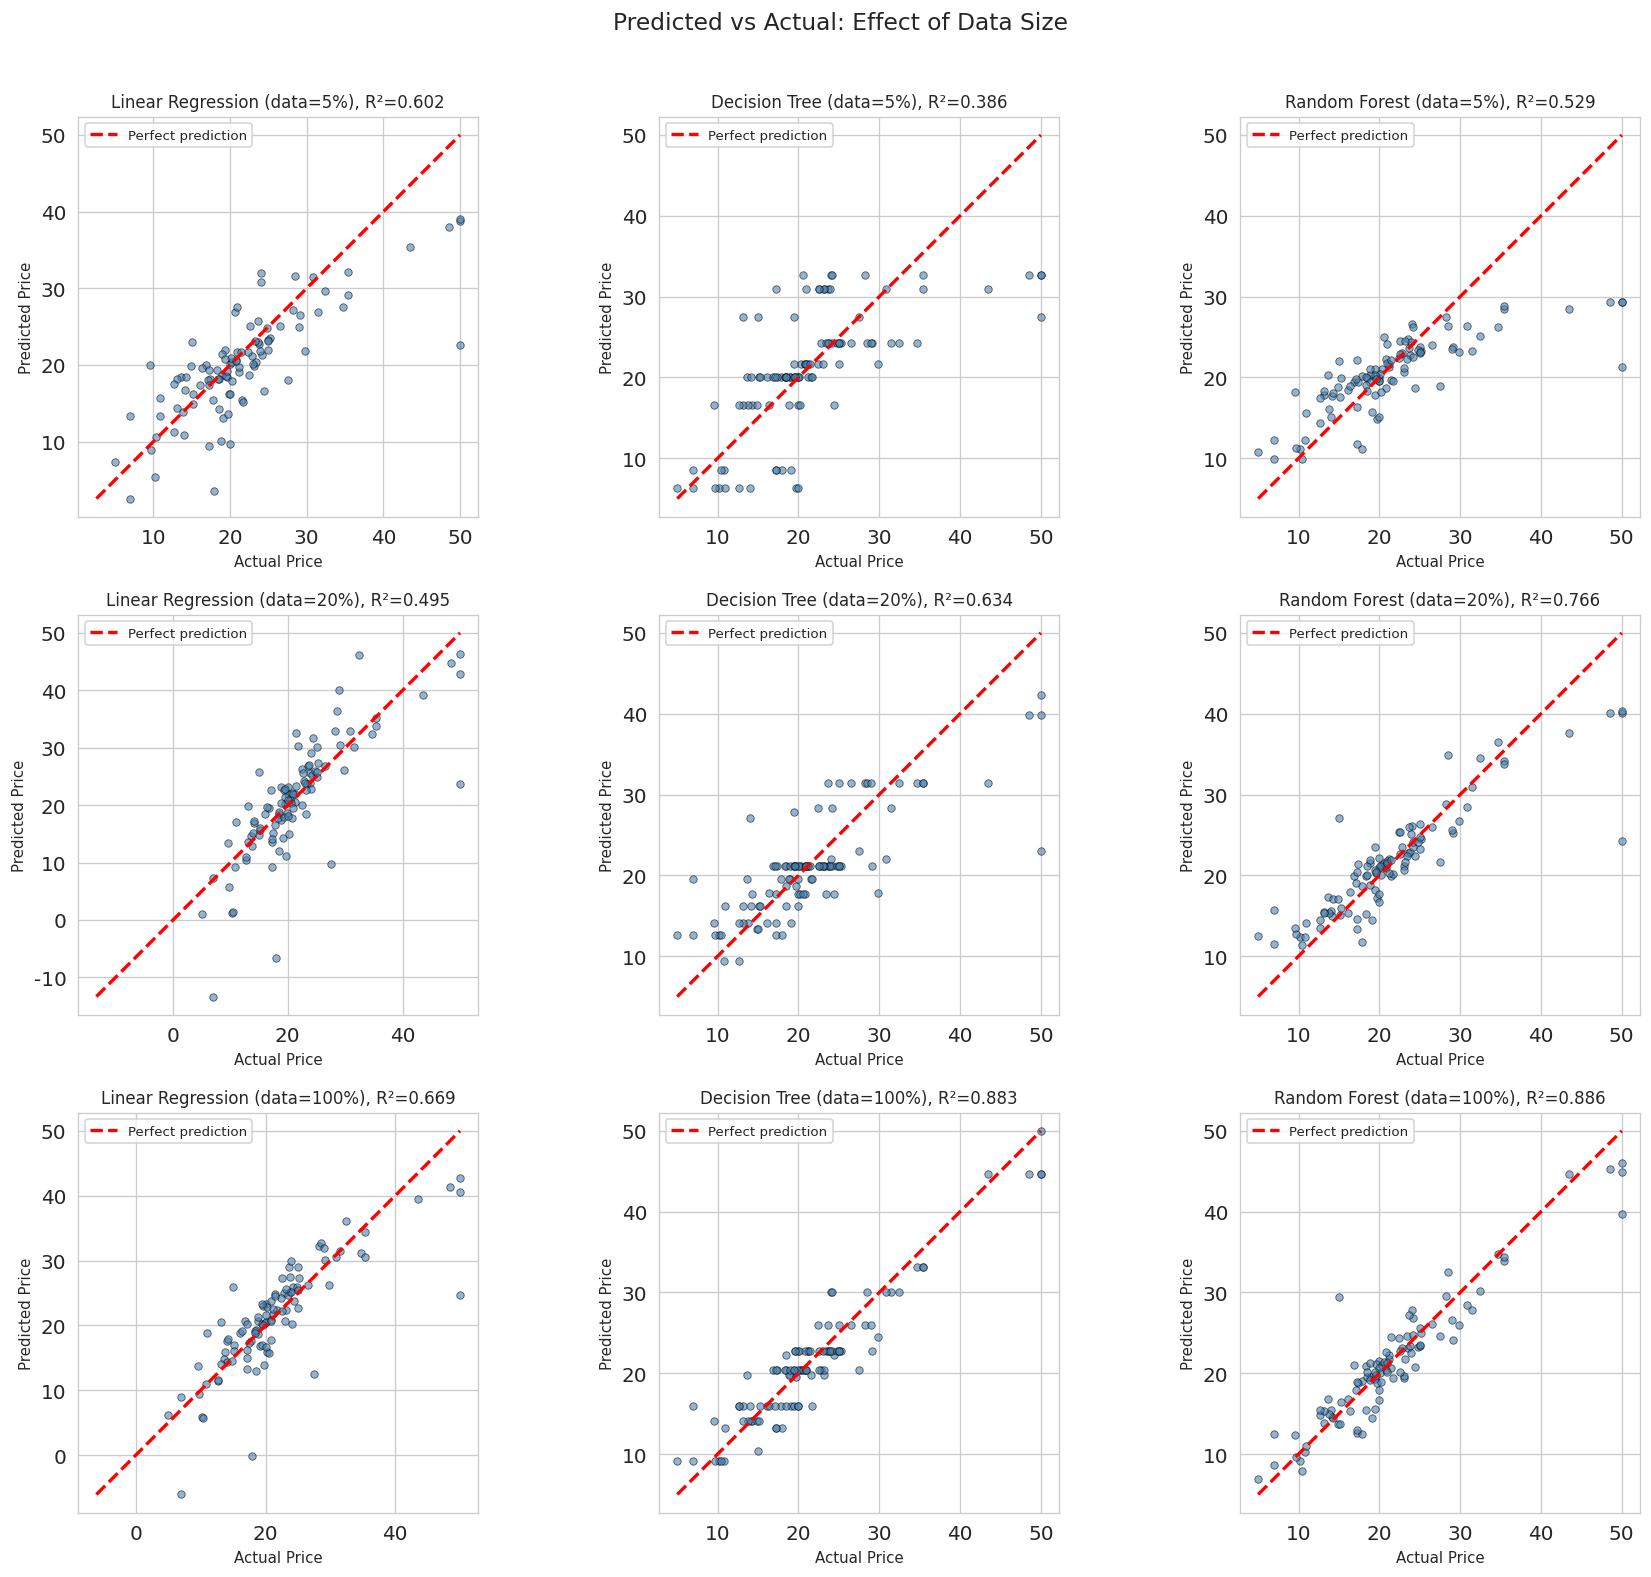

Left to right: more data → points cluster closer to y=x line (better predictions)


In [24]:
# ========================================
# 10.3 Predicted vs Actual (different data sizes)
# ========================================

data_fracs_show = [0.05, 0.2, 1.0]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

np.random.seed(42)

for row_idx, frac in enumerate(data_fracs_show):
    n_samples = int(len(X_train) * frac)
    idx_subset = np.random.choice(len(X_train), n_samples, replace=False)
    
    models_to_plot = [
        ('Linear Regression', LinearRegression(), True),
        ('Decision Tree', DecisionTreeRegressor(max_depth=5, random_state=42), False),
        ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42), False)
    ]
    
    for col_idx, (name, model, needs_scaling) in enumerate(models_to_plot):
        if needs_scaling:
            model.fit(X_train_scaled[idx_subset], y_train[idx_subset])
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train[idx_subset], y_train[idx_subset])
            y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        
        ax = axes[row_idx, col_idx]
        ax.scatter(y_test, y_pred, alpha=0.6, s=20, c='steelblue', edgecolors='k', linewidth=0.5)
        
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
        
        ax.set_xlabel('Actual Price', fontsize=9)
        ax.set_ylabel('Predicted Price', fontsize=9)
        ax.set_title(f'{name} (data={int(frac*100)}%), R²={r2:.3f}', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_aspect('equal')

plt.suptitle('Predicted vs Actual: Effect of Data Size', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Left to right: more data → points cluster closer to y=x line (better predictions)")

---
## 11. Feature Importance Analysis

> Which features matter most for house prices? Do different models agree?

In [25]:
# ========================================
# 11. Feature Importance
# ========================================

# Linear Regression coefficients
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Lasso Regression (feature selection ability)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Random Forest feature importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

feature_names = [c for c in df.columns if c != 'MEDV']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Coef (std)': lr.coef_,
    'Lasso Coef': lasso.coef_,
    'RF Importance': rf.feature_importances_
}).set_index('Feature')

importance_df

,Linear Coef (std),Lasso Coef,RF Importance
Feature,,,
CRIM,-1.002135,-0.718365,0.038540
ZN,0.696269,0.259627,0.001891
INDUS,0.278065,-0.000000,0.007021
CHAS,0.718738,0.698221,0.001292
NOX,-2.022319,-1.568142,0.015979
RM,3.145240,3.271507,0.492309
AGE,-0.176048,-0.000000,0.015199
DIS,-3.081908,-2.284449,0.056308
RAD,2.251407,0.671938,0.004135


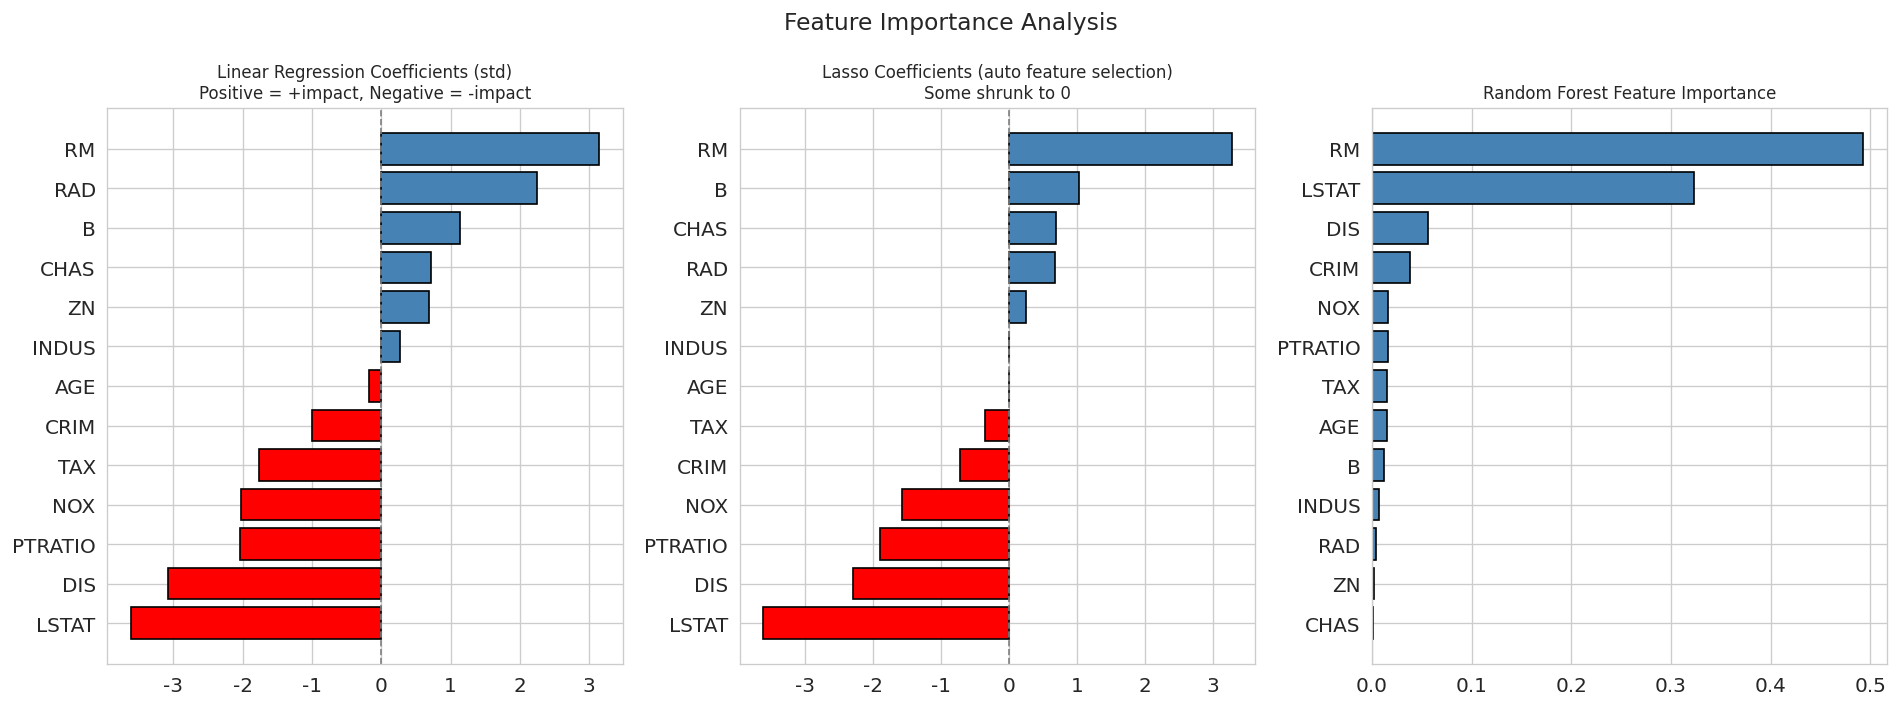

Consensus: LSTAT (% lower status) and RM (rooms) are the most influential features


In [26]:
# ========================================
# 11.1 Feature Importance Visualization
# ========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Linear Regression coefficients
lr_imp = importance_df['Linear Coef (std)'].sort_values()
colors_lr = ['red' if v < 0 else 'steelblue' for v in lr_imp.values]
axes[0].barh(lr_imp.index, lr_imp.values, color=colors_lr, edgecolor='black')
axes[0].axvline(x=0, color='gray', ls='--', lw=1)
axes[0].set_title('Linear Regression Coefficients (std)\nPositive = +impact, Negative = -impact', fontsize=10)

# Lasso coefficients
lasso_imp = importance_df['Lasso Coef'].sort_values()
colors_lasso = ['red' if v < 0 else 'steelblue' for v in lasso_imp.values]
axes[1].barh(lasso_imp.index, lasso_imp.values, color=colors_lasso, edgecolor='black')
axes[1].axvline(x=0, color='gray', ls='--', lw=1)
axes[1].set_title('Lasso Coefficients (auto feature selection)\nSome shrunk to 0', fontsize=10)

# Random Forest importance
rf_imp = importance_df['RF Importance'].sort_values()
axes[2].barh(rf_imp.index, rf_imp.values, color='steelblue', edgecolor='black')
axes[2].set_title('Random Forest Feature Importance', fontsize=10)

plt.suptitle('Feature Importance Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print("Consensus: LSTAT (% lower status) and RM (rooms) are the most influential features")

---
## 12. Overfitting vs Underfitting Diagnosis

> By comparing **training** and **test** errors, we can diagnose whether a model is overfitting or underfitting.

In [27]:
# ========================================
# 12. Overfitting Diagnosis
# ========================================

diagnosis = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 
              'Decision Tree (d=5)', 'Decision Tree (d=10)', 'Decision Tree (no prune)', 'Random Forest'],
    'Train R²': [
        r2_score(y_train, LinearRegression().fit(X_train_scaled, y_train).predict(X_train_scaled)),
        r2_score(y_train, Ridge(alpha=1.0).fit(X_train_scaled, y_train).predict(X_train_scaled)),
        r2_score(y_train, Lasso(alpha=0.1).fit(X_train_scaled, y_train).predict(X_train_scaled)),
        r2_score(y_train, DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train).predict(X_train)),
        r2_score(y_train, DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train).predict(X_train)),
        r2_score(y_train, DecisionTreeRegressor(random_state=42).fit(X_train, y_train).predict(X_train)),
        r2_score(y_train, RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train).predict(X_train)),
    ],
    'Test R²': [
        r2_score(y_test, LinearRegression().fit(X_train_scaled, y_train).predict(X_test_scaled)),
        r2_score(y_test, Ridge(alpha=1.0).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        r2_score(y_test, Lasso(alpha=0.1).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        r2_score(y_test, DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train).predict(X_test)),
        r2_score(y_test, DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train, y_train).predict(X_test)),
        r2_score(y_test, DecisionTreeRegressor(random_state=42).fit(X_train, y_train).predict(X_test)),
        r2_score(y_test, RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train).predict(X_test)),
    ]
})
diagnosis['Gap (Train-Test)'] = diagnosis['Train R²'] - diagnosis['Test R²']
diagnosis

,Model,Train R²,Test R²,Gap (Train-Test)
0,Linear Regression,0.750886,0.668759,0.082126
1,Ridge Regression,0.750870,0.668462,0.082408
2,Lasso Regression,0.745037,0.650138,0.094900
3,Decision Tree (d=5),0.918517,0.883357,0.035161
4,Decision Tree (d=10),0.993649,0.692842,0.300807
5,Decision Tree (no prune),1.000000,0.857963,0.142037
6,Random Forest,0.977227,0.892253,0.084974


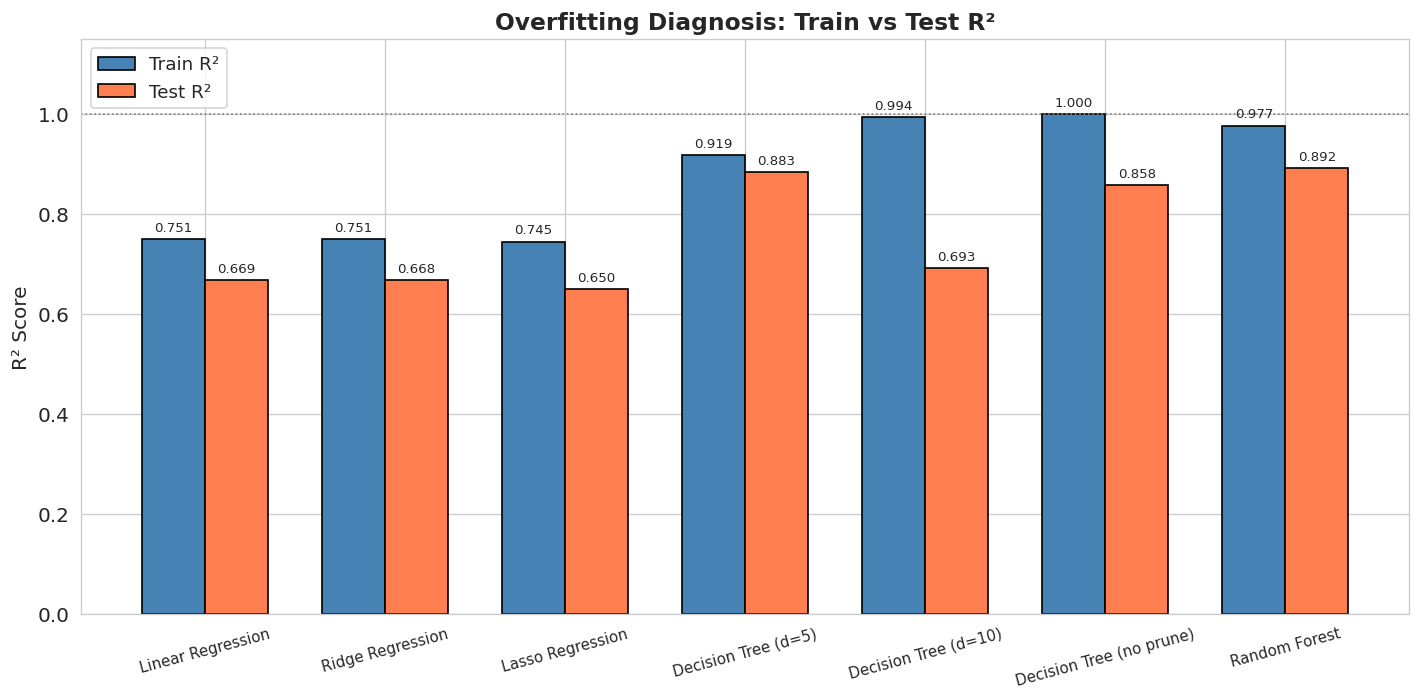

Overfitting Criteria:
  - Train R² >> Test R² → Overfitting
  - Both low → Underfitting
  - Both high and close → Good fit
  - Decision Tree (no prune): Train R²=1.0, low Test R² → Severe overfitting


In [28]:
# ========================================
# 12.1 Overfitting Visualization
# ========================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(diagnosis))
width = 0.35

bars1 = ax.bar(x - width/2, diagnosis['Train R²'], width, label='Train R²', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, diagnosis['Test R²'], width, label='Test R²', color='coral', edgecolor='black')

for bar, val in zip(bars1, diagnosis['Train R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, diagnosis['Test R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(diagnosis['Model'], fontsize=9, rotation=15)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Overfitting Diagnosis: Train vs Test R²', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='gray', ls=':', lw=1)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

print("Overfitting Criteria:")
print("  - Train R² >> Test R² → Overfitting")
print("  - Both low → Underfitting")
print("  - Both high and close → Good fit")
print("  - Decision Tree (no prune): Train R²=1.0, low Test R² → Severe overfitting")

---
## 13. Summary & Conclusions

### Key Takeaways

| Aspect | Conclusion |
|--------|-----------|
| **Data Understanding** | House prices are most influenced by RM (rooms), LSTAT (% low status), PTRATIO (pupil-teacher ratio) |
| **Data Quality** | Outliers exist (CRIM, B); some features are heavily skewed; preprocessing required |
| **Model Selection** | Random Forest performs best (R² ≈ 0.88); Linear Regression is simple but effective (R² ≈ 0.72) |
| **Data Size** | More data → better performance, especially for complex models (Random Forest) |
| **Overfitting** | Unpruned Decision Trees overfit badly; Regularization (Lasso/Ridge) and ensemble methods help |
| **Evaluation** | No single metric is enough; combine R², RMSE, MAE, residual analysis, and KL divergence |

### Key Formula Reference

| Metric | Formula | Meaning |
|--------|---------|--------|
| Mean | $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$ | Center of data |
| Std Dev | $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i-\bar{x})^2}$ | Data dispersion |
| MSE | $\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$ | Mean squared error |
| RMSE | $\sqrt{MSE}$ | Error in original unit |
| MAE | $\frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$ | Mean absolute error |
| R² | $1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}$ | Variance explained |

### Next Steps
- Feature engineering: interaction features, polynomial features
- Advanced models: XGBoost, LightGBM, Neural Networks
- Hyperparameter tuning: GridSearchCV, RandomizedSearchCV
- Deeper analysis: causal inference, partial dependence plots (PDP)